# *Importing Package*

In [ ]:
!pip install arch #-> Jika belum install arch

# =============================
# 🧰 Standard Libraries
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # Nonaktifkan warning

# =============================
# 📈 Statsmodels for Time Series
# =============================
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =============================
# 🔍 ARCH Model
# =============================
from arch import arch_model
from arch.univariate.base import ARCHModelResult  # Optional, untuk type hint

# =============================
# 📊 SciPy for Statistical Tests
# =============================
import scipy.stats as stats


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 8.9 MB/s eta 0:00:00


# Loading Dataset

In [ ]:
# Link data
# https://drive.google.com/file/d/1_wccoCcerXyPNzDeacA3I0zyG51oHIaE/view?usp=sharing

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1_wccoCcerXyPNzDeacA3I0zyG51oHIaE')
df.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,30/05/2025,1.731.187,1.735.581,1.737.232,1.716.421,NaN,"-0,36%"
1,29/05/2025,1.737.467,1.707.311,1.743.011,1.698.743,NaN,"1,77%"
2,28/05/2025,1.707.278,1.730.618,1.742.746,1.702.471,NaN,"-1,31%"
3,27/05/2025,1.729.984,1.744.568,1.747.769,1.719.789,NaN,"-0,89%"
4,26/05/2025,1.745.476,1.742.275,1.748.273,1.735.979,NaN,"0,23%"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     838 non-null    object 
 1   Terakhir    838 non-null    object 
 2   Pembukaan   838 non-null    object 
 3   Tertinggi   838 non-null    object 
 4   Terendah    838 non-null    object 
 5   Vol.        0 non-null      float64
 6   Perubahan%  838 non-null    object 
dtypes: float64(1), object(6)
memory usage: 46.0+ KB


Dapat diperhatikan bahwa kolom ```Tanggal``` memiliki tipe data object dan nilai lainnya pun memiliki tipe data object. Pun, data yang di ambil adalah data $3$ tahun terakhir sehingga dapat disimpulkan juga terdapat data yang hilang. Penanganan masalah tersebut akan dilakukan pada tahap *pre-processing*.

# *Pre-Processing*

## Penyesuaiaan Tipe Data

### Kolom Datetime

In [ ]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [ ]:
#biar kronologis
df_sorted = df.sort_values(by='Tanggal')
print(df_sorted.head())

       Tanggal Terakhir Pembukaan Tertinggi Terendah  Vol. Perubahan%
837 2022-05-31  860.950   867.090   870.807  860.454   NaN     -0,71%
836 2022-06-01  865.382   860.891   867.161  857.319   NaN      0,51%
835 2022-06-02  870.661   865.426   870.992  859.924   NaN      0,61%
834 2022-06-03  859.257   870.710   872.527  857.595   NaN     -1,31%
833 2022-06-05  859.620   859.257   860.230  858.829   NaN      0,04%


### Kolom Lainnya

Dilakukan pengubahan tipe data dari object ke float dengan strategi prosedural:
1. Menghapus $(.)$;
2. Mengganti $(,)$ dengan $(.)$
3. Mengubahnya menjadi float

In [ ]:
def to_float(val):
    if pd.isna(val):
        return None
    val = val.replace('.', '').replace(',', '.')
    try:
        return float(val)
    except:
        return None

num_cols = ["Terakhir", "Pembukaan", "Tertinggi", "Terendah"]
for col in num_cols:
    df_sorted[col] = df_sorted[col].apply(to_float)

## Pemilihan Variabel Target Univariat

Sebagai Fokus observasi, akan digunakan kolom ```Terakhir``` yang merupakan harga penutupan (terakhir sebelum pasar tutup).

In [ ]:
df_sorted.drop(columns=['Vol.', 'Perubahan%', 'Pembukaan', 'Tertinggi', 'Terendah'], inplace=True)

Berikut merupakan visualisasi data runtun waktu dari variabel harga ```Terakhir```

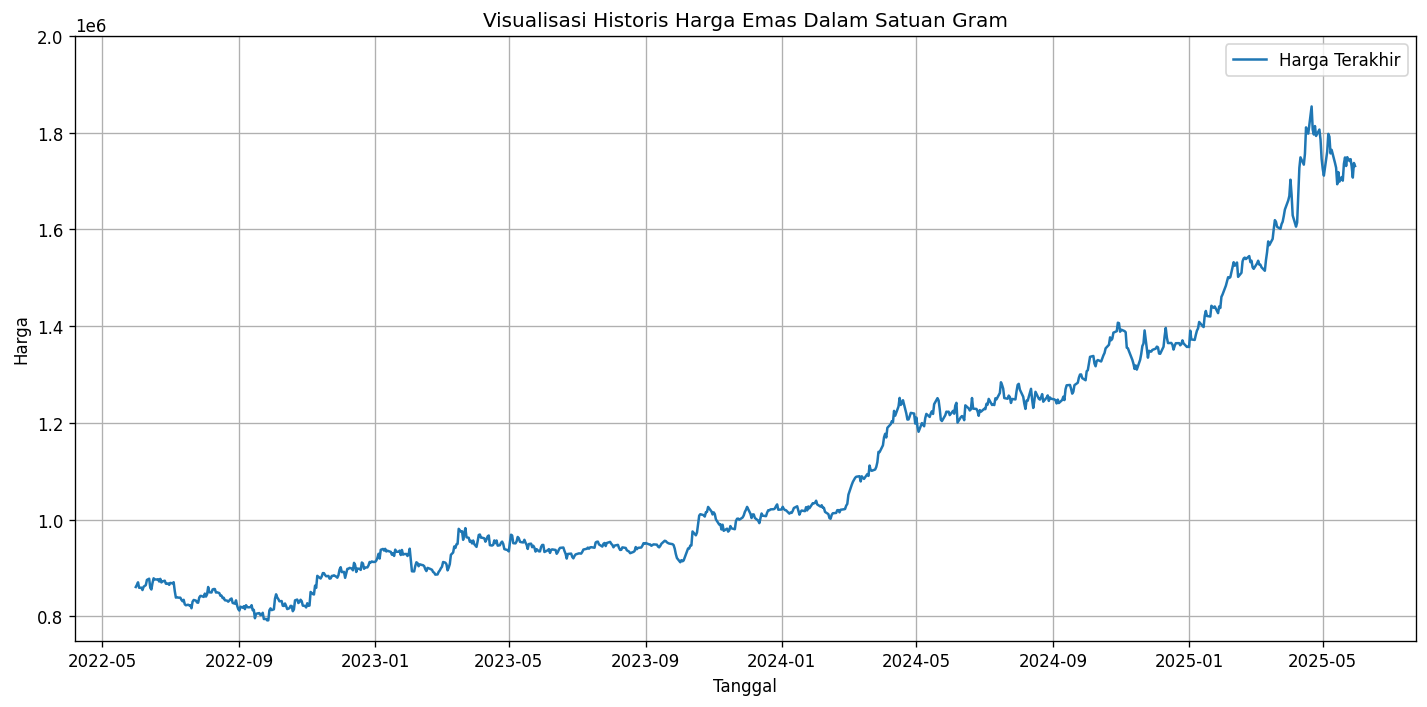

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['Tanggal'], df_sorted['Terakhir'], label='Harga Terakhir')
plt.ylim(750000, 2000000)

plt.title('Visualisasi Historis Harga Emas Dalam Satuan Gram')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Berikut merupakan ringkasan *dataframe* yang sudah dilakukan penyesuaian tipe data dan pemilihan fitur.

In [ ]:
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838 entries, 837 to 0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Tanggal   838 non-null    datetime64[ns]
 1   Terakhir  838 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.6 KB


## Penanganan Data Yang Hilang

Data yang diambil merupakan data dari $31$ Mei $2022$ sampai dengan $30$ Mei $2025$ yang seharusnya memiliki $1095$ hari secara *timestamp*. Hal ini mengindikasikan adanya data yang hilang pada kolom ```Tanggal```. Untuk itu akan dilakukan peninjaun secara visual terhadap hal tersebut.

Untuk melihat data yang hilang akan dilakukan *upsampling* adalah mengurangi jumlah sampel atau mengurangi detail data dari interval waktu yang lebih kecil ke interval waktu yang lebih besar. Pada kasus ini akan dilakukan *upsampling* dari *weekly* ke *daily*

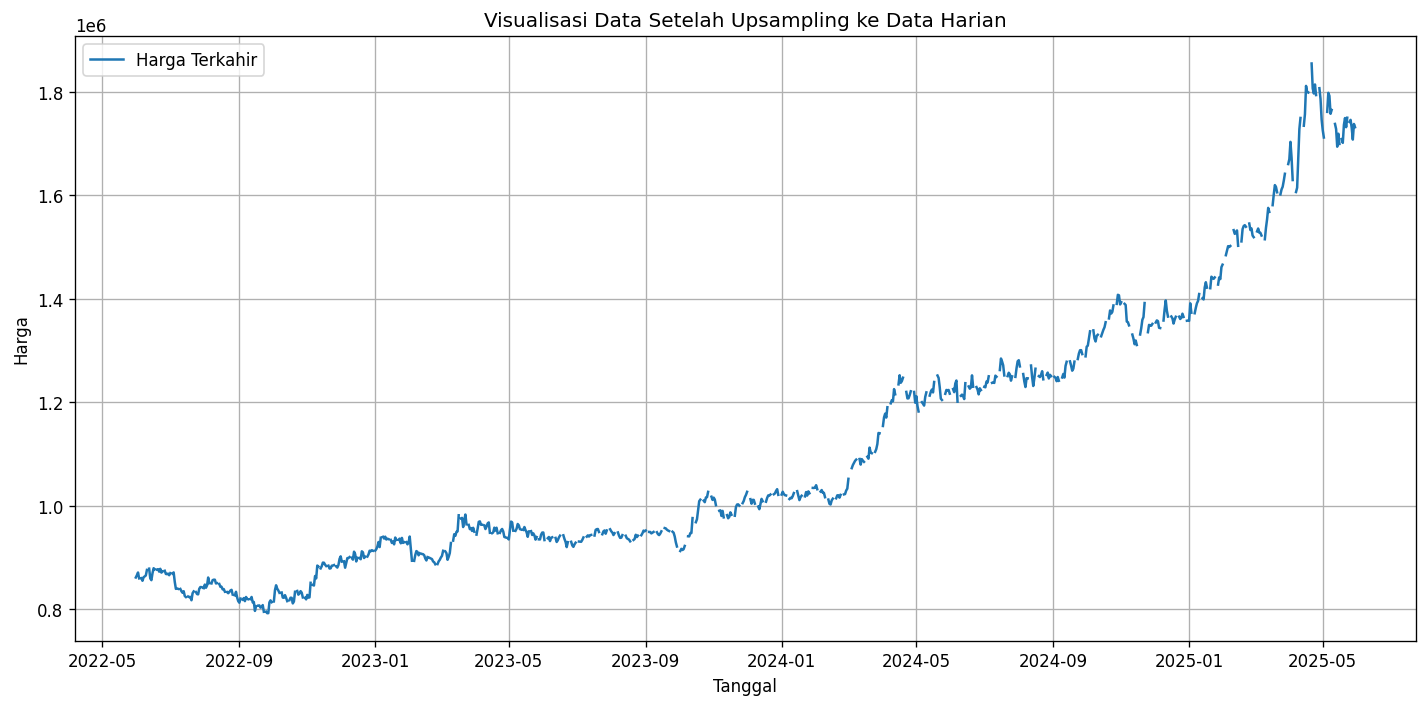

In [ ]:
#Upsampling
df_resampled = df_sorted.set_index('Tanggal').resample('D')['Terakhir'].mean()

# jadiinindex
df_resampled = df_resampled.reset_index()

# Visualisasi data setelah resample
plt.figure(figsize=(12, 6))
plt.plot(df_resampled['Tanggal'], df_resampled['Terakhir'], label='Harga Terkahir')

plt.title('Visualisasi Data Setelah Upsampling ke Data Harian')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_resampled.shape

(1096, 2)

Dapat ditunjukkan bahwasannya terdapat data yang hilang di beberapa pa interval waktu. Selanjutnya, akan dihitung banyaknya *missing value* pada data tersebut.

In [ ]:
# missing data setelah resampling
print("\nMissing values per column after weekly resampling:")
print(df_resampled.isnull().sum())


Missing values per column after weekly resampling:
Tanggal       0
Terakhir    258
dtype: int64


Hasil tersebut menunjukkan bahwa data yang hilang sebnayak $258$ baris pada kolom ```Terakhir```.

### Imputasi

Data yang hilang akan dilakukan imputasi dengan strategi prosedural sebagai berikut:
1. *Rolling Mean* $7$ hari untuk menangkap jangka pendek
2. *Rolling Mean* $30$ hari untuk menangkap jangka panjang.
3. Interpolasi.
4. *Shifting* untuk backup plan jika missing value tidak teratasi.

Metode ini tepat dikarenakan berjenjang dan memanfaatkan dependensi waktu.

In [ ]:
def impute_missing_time_series(df, date_col, value_col, window1=7, window2=30, shift_period=7, method='linear'):

    df = df.sort_values(by=date_col).copy()

    # rollingmean 7 buat jangka pendek
    df[value_col] = df[value_col].fillna(df[value_col].rolling(window=window1, min_periods=1).mean())

    # rollingmean 30 buat jangka panjnag
    df[value_col] = df[value_col].fillna(df[value_col].rolling(window=window2, min_periods=1).mean())

    # Step 3: interpolasi linear aja, ga banyak data yang ilang
    df[value_col] = df[value_col].interpolate(method=method)

    # Step 4: kalo masih nan isi sama data sebelum atau setelahnya
    df[value_col] = df[value_col].fillna(df[value_col].shift(shift_period))
    df[value_col] = df[value_col].fillna(df[value_col].shift(-shift_period))

    return df

In [ ]:
df_resampled = impute_missing_time_series(df_resampled, 'Tanggal', 'Terakhir', window1=5, window2=15)
print("Missing Value sudah teratasi")

Missing Value sudah teratasi


### Validasi Keberhasilan Imputasi

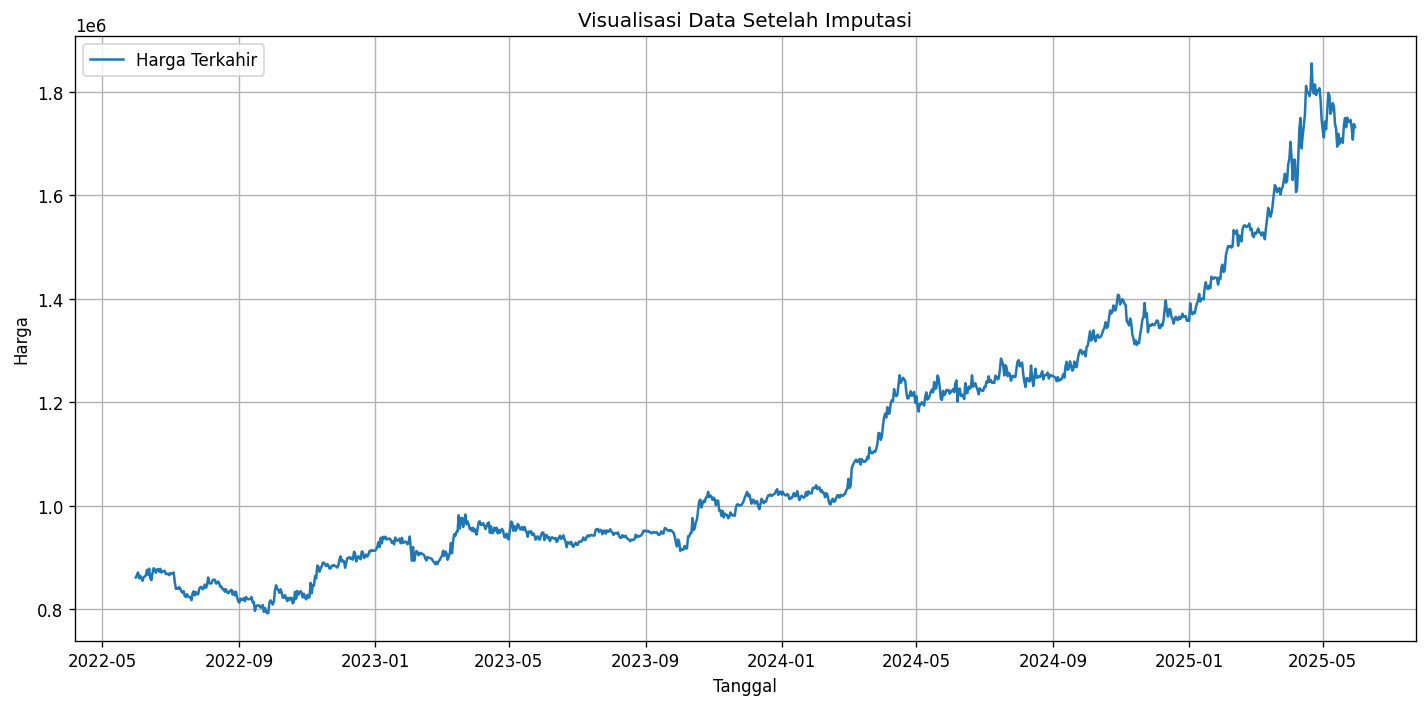

In [ ]:
# Visualisasi data setelah imputasi
plt.figure(figsize=(12, 6))
plt.plot(df_resampled['Tanggal'], df_resampled['Terakhir'], label='Harga Terkahir')

plt.title('Visualisasi Data Setelah Imputasi')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_resampled

,Tanggal,Terakhir
0,2022-05-31,860950.0
1,2022-06-01,865382.0
2,2022-06-02,870661.0
3,2022-06-03,859257.0
4,2022-06-04,864062.5
...,...,...
1091,2025-05-26,1745476.0
1092,2025-05-27,1729984.0
1093,2025-05-28,1707278.0
1094,2025-05-29,1737467.0


In [ ]:
df_resampled.to_csv('data_emas_terbaru.csv', index=False)

Setelah melakukan imputasi data yang hilang, proses *pre-processing* dinyatakan selesai.

# Analisis Time Series

## Deteksi Seasonality

Seasonality pada data di tes menggunakan dua hal
1. Dekomposisi Seasonal
2. Periodogam

### Dekomposisi Seasonal

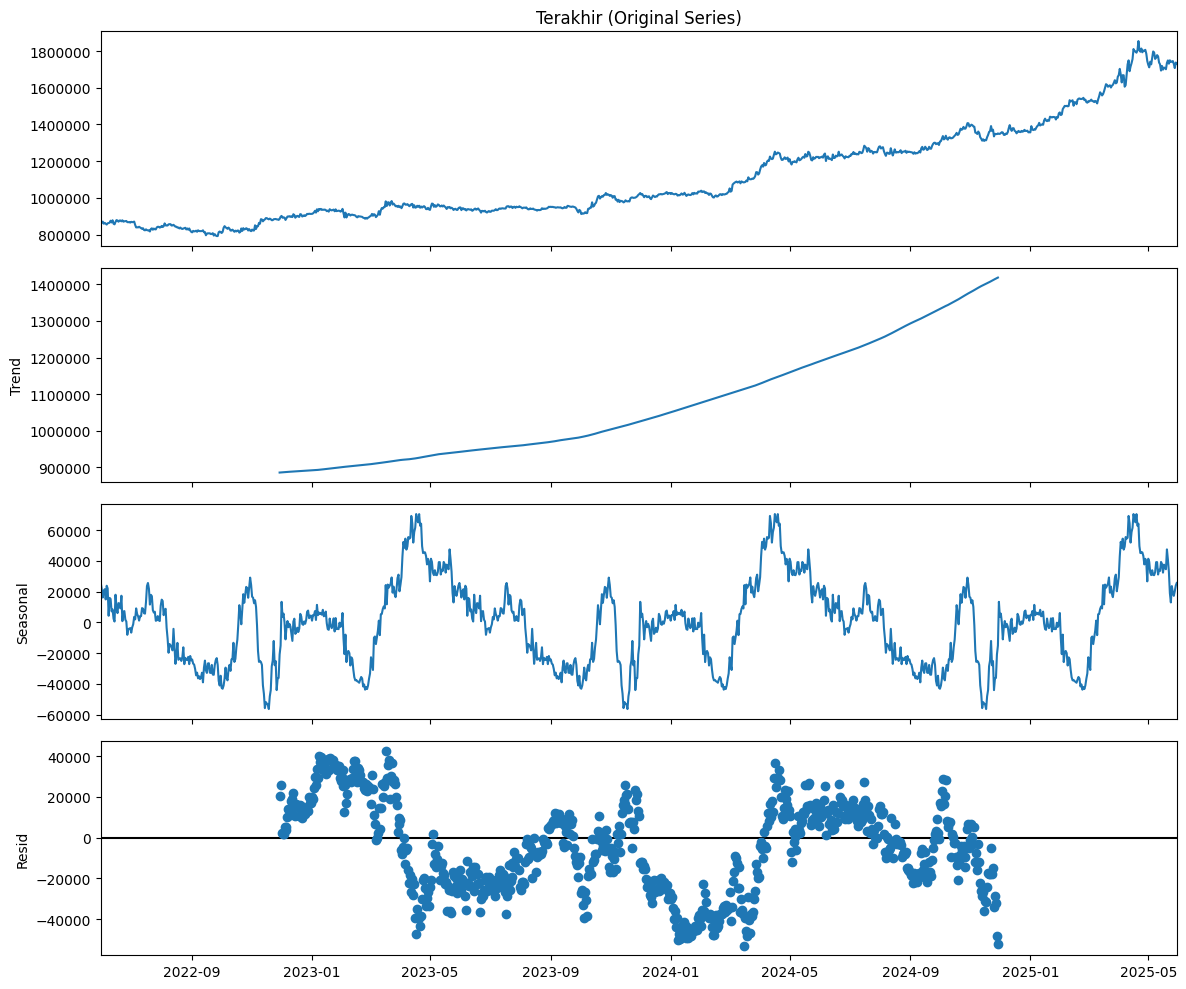

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_resampled_indexed = df_resampled.set_index('Tanggal')
decomposition = seasonal_decompose(df_resampled_indexed['Terakhir'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 10)

ax1 = fig.axes[0]
ax1.set_title('Terakhir (Original Series)')

for ax in fig.axes:
    ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

Meskipun tidak terlihat jelas, terdapat pola perulangan yang kasar pada seasonal. Untuk memperkuat argumen ini akan digunakan periodogram.

### Periodogram

Konsep  periodogram adalah melihat apakah ada proporsi siklus per hari yang signfikan (memiliki spike). Berikut contoh interpretasi periodogram
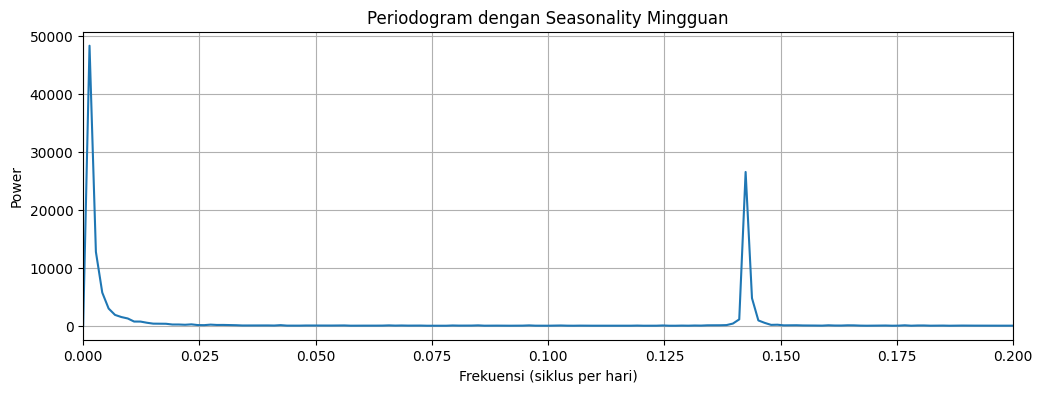
Dapat dilihat bahwa terdapat spike di sekitar frekunesi $\approx 0.14$ yang approximately $0.14\approx 1/7$. Hal ini menunjukan pada contoh, selain data memiliki spike di sekitar nilai 0 (yang menunjukan tren jangka panjang), terdapat juga spike di $0,14$ ada pola yang terulang secara teratur setiap 7 hari (karena $1 / 0.14 \approx 7$).Ini disebut musiman mingguan.

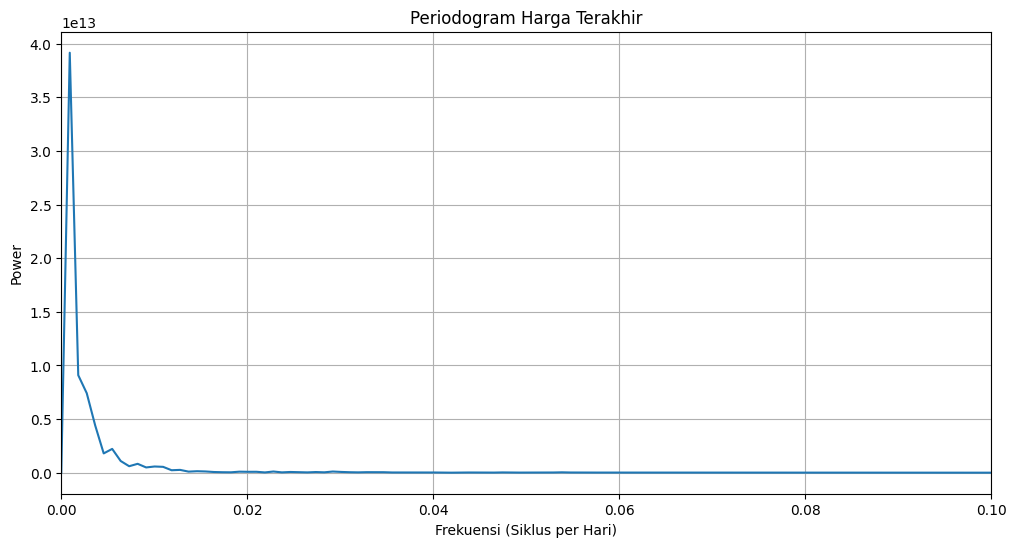

In [ ]:
from scipy.signal import periodogram

# Hitung periodogram
freqencies, power = periodogram(df_resampled['Terakhir'].dropna(), fs=1.0/1.0) # fs=1.0/1.0 karena data harian

# Plot periodogram
plt.figure(figsize=(12, 6))
plt.plot(freqencies, power)
plt.title('Periodogram Harga Terakhir')
plt.xlabel('Frekuensi (Siklus per Hari)')
plt.ylabel('Power')
plt.grid(True)
plt.xlim(0, 0.1) # Batasi frekuensi untuk melihat pola jangka panjang (frekuensi rendah)
plt.show()

Dapat diperhatikan bahwa tidak ada spike selain di persekitaran 0 yang menunjukan tren jangka panjang. Meskipun decomposition mengindikasikan adanya pola musiman, periodogram menunjukkan bahwa pola tersebut tidak cukup kuat atau konsisten dalam satu frekuensi tertentu. Kemungkinan, seasonality yang muncul bersifat lemah, tidak periodik secara kaku, atau bergeser sepanjang waktu.

### ACF dan PACF

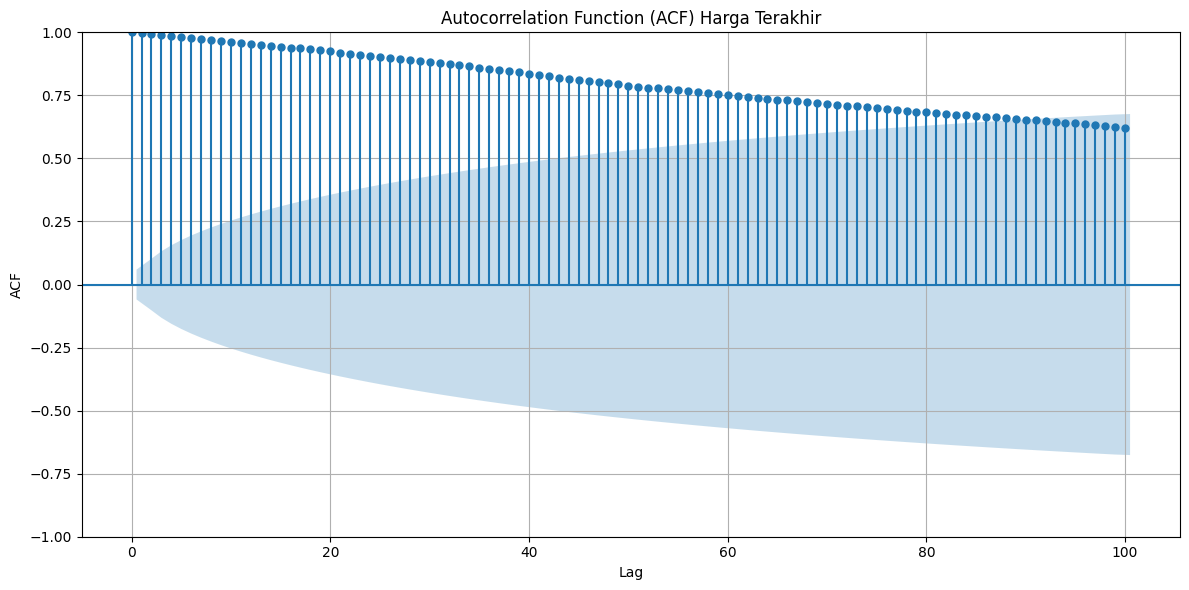

In [ ]:
# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(df_resampled['Terakhir'].dropna(), lags=100, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) Harga Terakhir')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(True)
plt.tight_layout()
plt.show()

Spike yang ada justru merupakan penurunan lambat yang merupakan ciri dari data non-stasioner.

### Kesimpulan

Meskipun *decomposition* mengindikasikan adanya pola musiman, periodogram menunjukkan bahwa pola tersebut tidak cukup kuat atau konsisten dalam satu frekuensi tertentu. Kemungkinan, *seasonality* yang muncul bersifat lemah, tidak periodik secara kaku, atau bergeser sepanjang waktu.

Akan dilakukan Uji Stasioner

## Uji Stasioner

Stasioneritas akan diuji dengan dua cara:
1. Uji ADF
2. Uji KPPS
3. Plot Mean dan Variansi

### Uji ADF

 Uji ADF berfungsi untuk menguji apakah deret waktu memiliki akar unit (unit root), yang merupakan indikator bahwa deret waktu tidak stasioner.
 $$H_0: \text{Random Walk}$$
 $$H_1: \text{Stasioner}$$
Jika *p-value* $<\alpha$, maka $H_0$ ditolak.

In [ ]:
def adf(ts):
  result = adfuller(ts)
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

  if result[1] <= 0.05:
    print("Conclusion: Reject H0 - The time series is stationary.")
  else:
    print("Conclusion: Fail to reject H0 - The time series is non-stationary.")

adf(df_resampled['Terakhir'].dropna())

ADF Statistic: 1.5956141557574135
p-value: 0.9978443580184213
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
Conclusion: Fail to reject H0 - The time series is non-stationary.


Data Tidak Stasioner

### Uji KPPS
 Uji KPPS berfungsi untuk menguji apakah deret waktu stasioner di sekitar level atau tren deterministik. Ini sering digunakan sebagai pelengkap uji ADF.
  $$H_0: \text{Stasioner}$$
 $$H_1: \text{Random Walk}$$
Jika *p-value* $<\alpha$, maka $H_0$ ditolak.

In [ ]:
def kpss(ts):
  result = sm.tsa.kpss(ts.dropna(), regression='c') # 'c' for stationary around a constant mean
  print('KPSS Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[3].items():
      print('\t%s: %.3f' % (key, value))

  if result[1] <= 0.05:
      print("Conclusion: Reject H0 - The time series is non-stationary.")
  else:
      print("Conclusion: Fail to reject H0 - The time series is stationary.")

kpss(df_resampled['Terakhir'])

KPSS Statistic: 4.67137074802806
p-value: 0.01
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Conclusion: Reject H0 - The time series is non-stationary.


<ipython-input-21-1324213228>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = sm.tsa.kpss(ts.dropna(), regression='c') # 'c' for stationary around a constant mean


Data Tidak Stasioner

### Plot Mean dan Variansi

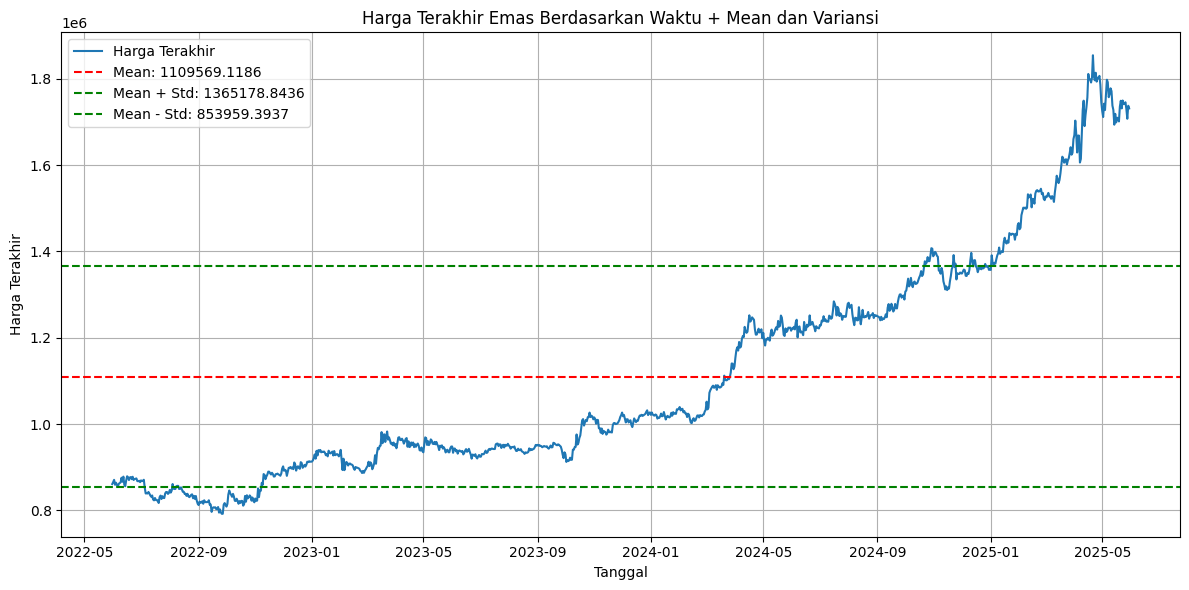

In [ ]:
mean = df_resampled['Terakhir'].mean()
std = df_resampled['Terakhir'].std()

plt.figure(figsize=(12, 6))
plt.plot(df_resampled['Tanggal'], df_resampled['Terakhir'], label='Harga Terakhir')

# Tambahkan garis horizontal untuk mean
plt.axhline(mean, color='red', linestyle='--', label=f'Mean: {mean:.4f}')

# Tambahkan garis horizontal untuk mean + std dan mean - std
plt.axhline(mean + std, color='green', linestyle='--', label=f'Mean + Std: {(mean + std):.4f}')
plt.axhline(mean - std, color='green', linestyle='--', label=f'Mean - Std: {(mean - std):.4f}')


plt.title('Harga Terakhir Emas Berdasarkan Waktu + Mean dan Variansi')
plt.xlabel('Tanggal')
plt.ylabel('Harga Terakhir')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Mean tidak konstan mengakibatkan data tidak stasioner

In [ ]:
def white_test(residuals):
  """
  Performs the White test for heteroskedasticity.

  Args:
    residuals (pd.Series or np.array): Residuals from a time series model.
  """
  try:
    lm, lm_pvalue, fvalue, f_pvalue = het_arch(residuals, nlags=0)

    print(f'White Test (Lagrange Multiplier Test) Results:')
    print(f'  LM Statistic: {lm:.4f}')
    print(f'  LM p-value: {lm_pvalue:.4f}')
    print(f'  F-statistic: {fvalue:.4f}')
    print(f'  F p-value: {f_pvalue:.4f}')

    alpha = 0.05
    if lm_pvalue < alpha:
      print(f"Conclusion: Reject H0 - Heteroskedasticity (non-constant variance) is present (p-value = {lm_pvalue:.4f}).")
    else:
      print(f"Conclusion: Fail to reject H0 - No significant evidence of heteroskedasticity (constant variance) (p-value = {lm_pvalue:.4f}).")

  except Exception as e:
      print(f"An error occurred during the White test: {e}")

dfcek = df_resampled['Terakhir'].dropna()

print("\n--- White Test for Variance Constancy ---")
white_test(dfcek)



--- White Test for Variance Constancy ---
White Test (Lagrange Multiplier Test) Results:
  LM Statistic: 0.0000
  LM p-value: nan
  F-statistic: nan
  F p-value: nan
Conclusion: Fail to reject H0 - No significant evidence of heteroskedasticity (constant variance) (p-value = nan).


Dikarenakan White Test menghasilkan $H_0$ yang gagal ditolak, artinya variansi konstan.

### Kesimpulan

Meskipun variansi data konstan, akan tetapi dikarenakan mean tidak konstan, maka data disimpulkan tidak stasioner dan diperlukan diferensiasi.

## Diferensiasi Data

Diferensiasi data dilakukan berdasarkan dua uji stasioneritas utama, yaitu
1. Uji KPPS
2. Uji ADF

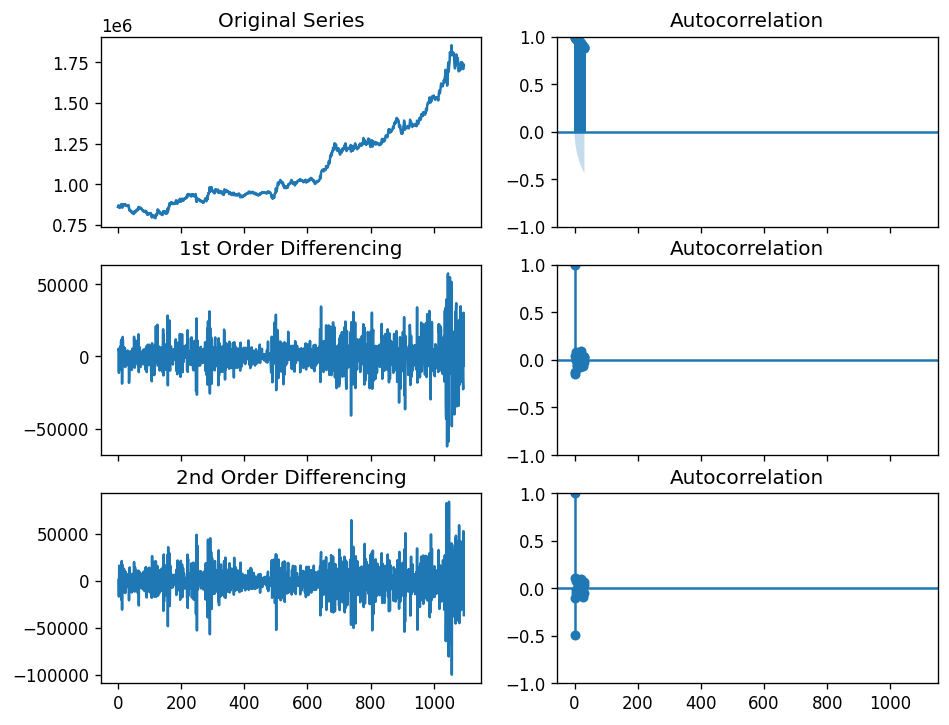

In [ ]:
#Inisialisasi Plot bersama
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

#Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df_resampled.Terakhir); axes[0, 0].set_title('Original Series')
plot_acf(df_resampled.Terakhir, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df_resampled.Terakhir.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df_resampled.Terakhir.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df_resampled.Terakhir.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df_resampled.Terakhir.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

*First-order differencing* sudah cukup untuk menghilangkan non-stasioneritas. Lebih lanjut akan ditinjau pada Uji KPPS dan Uji ADF.



In [ ]:
df_resampled['Terakhir_diff'] = df_resampled['Terakhir'].diff()

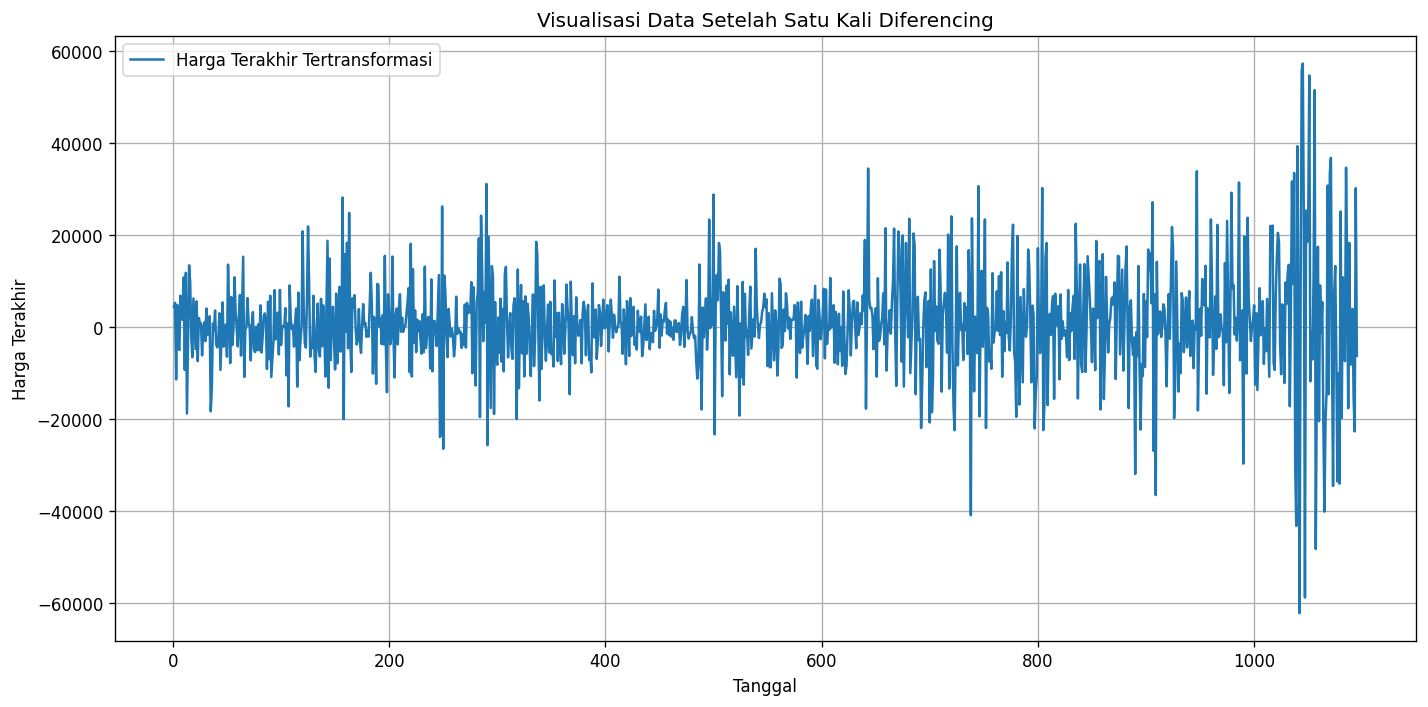

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_resampled.index, df_resampled['Terakhir_diff'], label='Harga Terakhir Tertransformasi')
plt.title('Visualisasi Data Setelah Satu Kali Diferencing')
plt.xlabel('Tanggal')
plt.ylabel('Harga Terakhir')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Dapat disimpulkan ```Terakhir_diff``` menghaislkan deret yang stasioner

## Deteksi Seasonal Part 2

Beberapa literatur menyatakan bahwasannya musiman dapat diketahui pada ACF dan PACF dimana spike yang periodik di lag tertentu menandakan adanya komponen musiman.

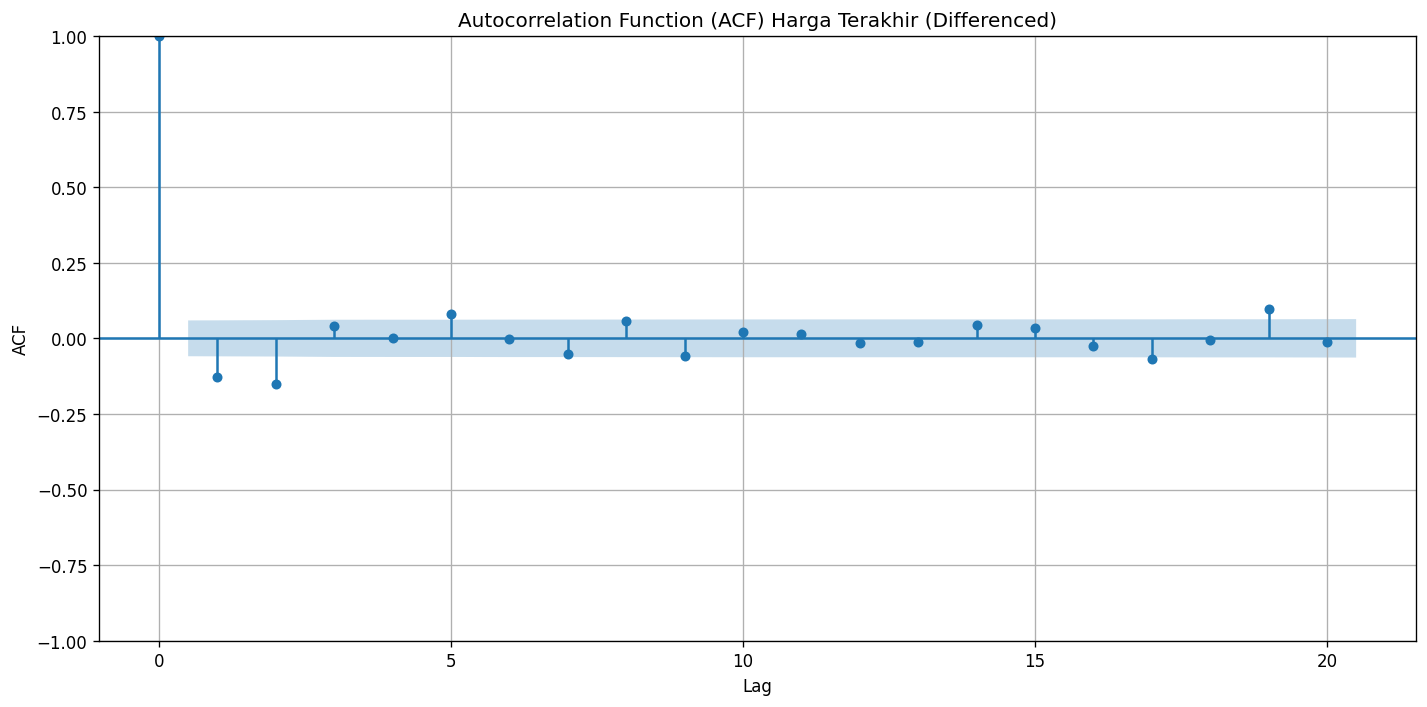

In [ ]:
# ACF
plt.figure(figsize=(12, 6))
plot_acf(df_resampled['Terakhir_diff'].dropna(), lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) Harga Terakhir (Differenced)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(True)
plt.tight_layout()
plt.show()

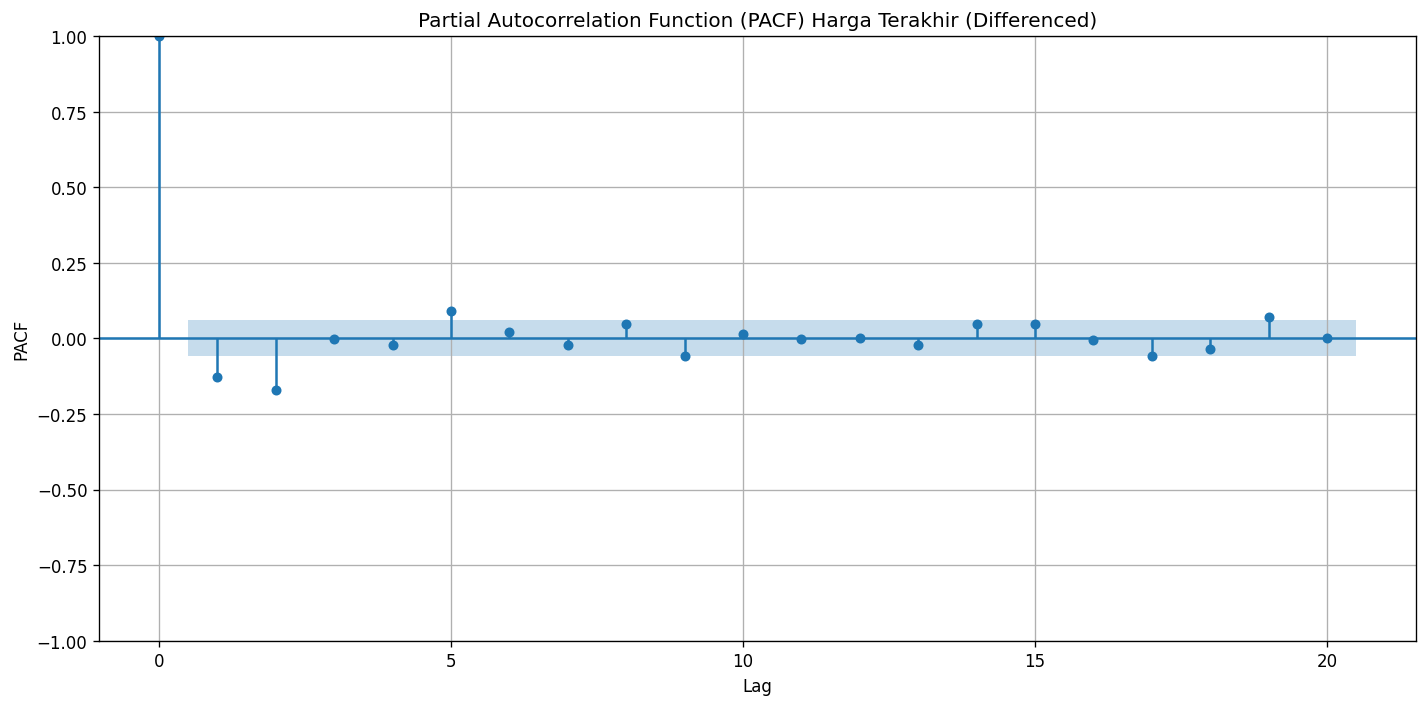

In [ ]:
# PACF
plt.figure(figsize=(12, 6))
plot_pacf(df_resampled['Terakhir_diff'].dropna(), lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) Harga Terakhir (Differenced)')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.grid(True)
plt.tight_layout()
plt.show()

Dapat diperhatikan ACF dan PACF tidak menunjukkan adanya lag signfikan yang periodik, pun hampir semuanya ada didalam CI. Dapat dipastikan data setelah terdiferensiasi tidak memiliki pola musiman.

# Spesifikasi Model

Akan dilakukan pencarian masing-masing order $ARIMA (p,d,q)$

## Mencari order q (ACF)

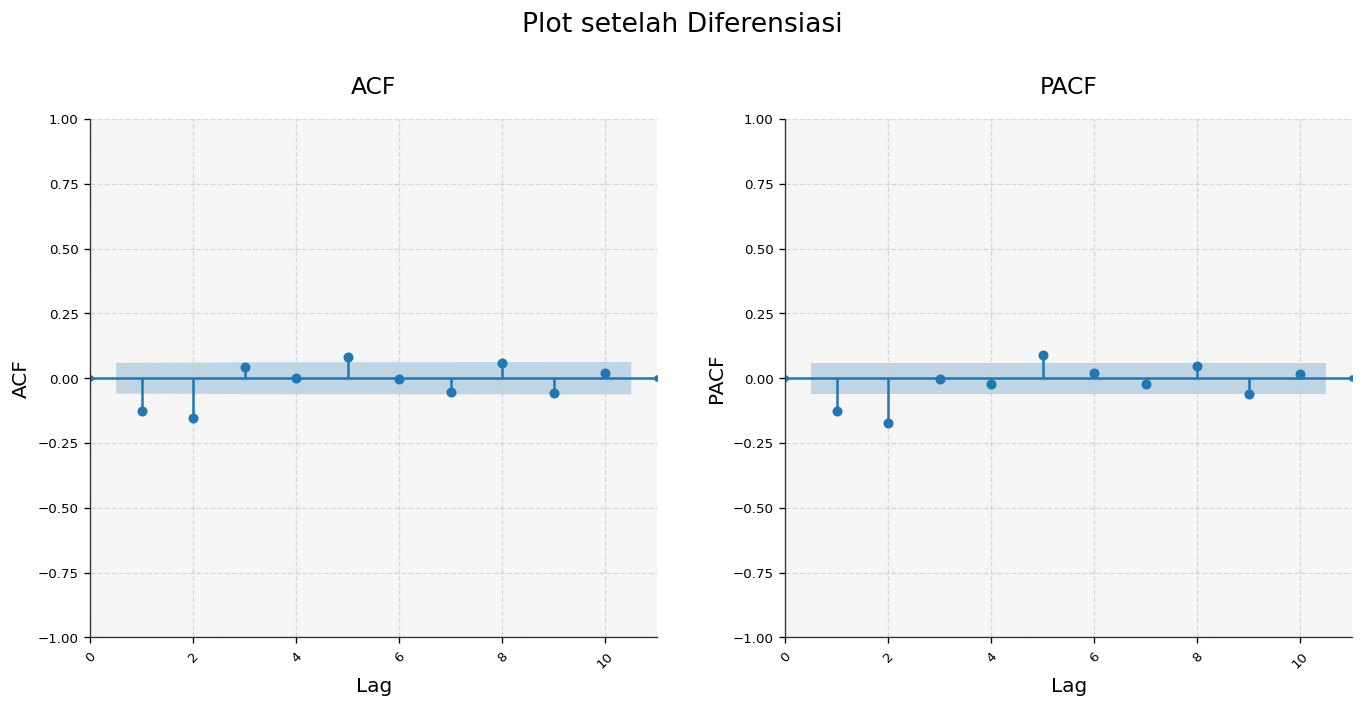

In [ ]:
data_diff = df_resampled['Terakhir_diff'].dropna()

lags = 10

# Setting aja
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.facecolor': '#f5f5f5',
    'grid.color': '#cccccc',
    'grid.linestyle': '--',
    'axes.edgecolor': '#333333',
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',
    'lines.markersize': 3,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']
})

fig, axes = plt.subplots(1, 2, sharey=False)

# --- Plot ACF ---
plot_acf(data_diff, ax=axes[0], lags=lags, alpha=0.05, zero=False)
axes[0].set_title('ACF', fontsize=14, pad=15)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Plot PACF ---
plot_pacf(data_diff, ax=axes[1], lags=lags, method='ywm', alpha=0.05, zero=False)
axes[1].set_title('PACF', fontsize=14, pad=15)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.suptitle('Plot setelah Diferensiasi', fontsize=16, y=1.02)
plt.show()

Dapat diidentifikasi:
- Pada ACF, dapat dipunyai bahwsa terdapat spike pada lag $1$ dan lag $2$. Akibatnya, dapat diperoleh $q=2$.
- Pada PACF, dapat dipunyai bahwsa terdapat spike pada lag $1$ dan lag $2$. Akibatnya, dapat diperoleh $p=2$.

## Kesimpulan

Didapatkan model $ARIMA(2,0,2)$ terhadap variabel ```Terakhir_diff```

Berdasarkan plot ACF diajukan model
$$
\Delta Y_t = \phi_1 \Delta Y_{t-1} + \phi_2 \Delta Y_{t-2} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}
$$


# *Fitting* ARIMA

> **Perlu diperhatikan !**
> data setelah differencing **TIDAK PERLU DIIMPUTASI** dikarenakan dapat mengakibatkan bias.
> Gunakan $ARIMA (p,d,q)$ terhadap data fitur asli, ```Terakhir```.

**Interpretasi ARIMA**
- Log Likelihood: semakin tinggi (kurang negatif) semakin baik.
- AIC (Akaike Information Criterion): lebih kecil = lebih baik (untuk pemilihan model).
- Banyak parameter signfikan

**Model Diagnostik**
- Ljung Box (Q): Menguji autokorelasi residual.
$$H_0: \text{Tidak ada autokorelasi}$$
Jika p < 0.05 → model belum menangkap pola time series dengan baik.
- Jarque-Bera Test: Menguji normalitas residual.
$$H0: \text{residual berdistribusi normal}$$
Jika p < 0.05 → residual tidak normal
- Heteroskadastisitas (H) : Menguji apakah residual memiliki varians konstan.
$$H0: \text{tidak ada heteroskedastisitas}$$
Jika p < 0.05 → pertimbangkan menambahkan GARCH.

Pemodelan menggunakan data asli

In [ ]:
# Fit ARIMA model (2,1,2)
model = ARIMA(df_resampled['Terakhir'], order=(2, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               Terakhir   No. Observations:                 1096
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -11759.033
Date:                Tue, 10 Jun 2025   AIC                          23528.066
Time:                        04:43:32   BIC                          23553.058
Sample:                             0   HQIC                         23537.523
                               - 1096                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6454      0.113      5.718      0.000       0.424       0.867
ar.L2         -0.8810      0.101     -8.701      0.000      -1.079      -0.683
ma.L1         -0.6538      0.116     -5.617      0.0

> Perlu diperhatikan bahwa warning kedua mengatakan bahwasannya standard error kemungkinan tidak stabil. Nilai yang sangat besar (seperti 1.47e+32, yang berarti 1.47 diikuti oleh 32 angka nol) menunjukkan bahwa matriks tersebut sangat mendekati singular. Diperlukan **transformasi log** sedemikian sehingga nilai kovarians wajar dan tidak mendekati singular.

## Transformasi Log

In [ ]:
df_resampled['Terakhir_log'] = np.log(df_resampled['Terakhir'])

## ACF PACF BAru

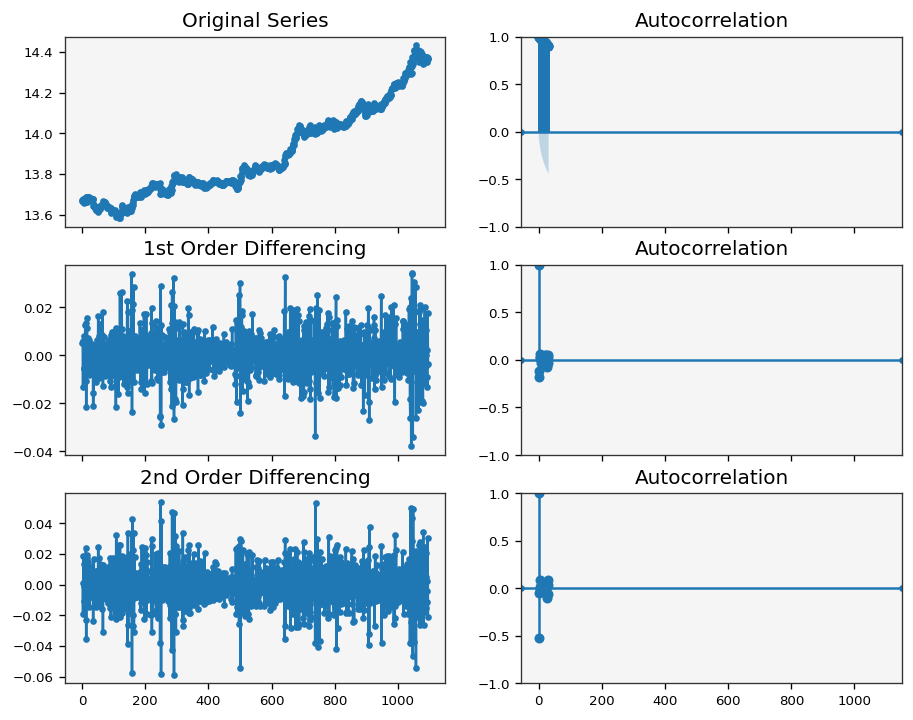

In [ ]:
#Inisialisasi Plot bersama
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

#Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df_resampled.Terakhir_log); axes[0, 0].set_title('Original Series')
plot_acf(df_resampled.Terakhir_log, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df_resampled.Terakhir_log.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df_resampled.Terakhir_log.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df_resampled.Terakhir_log.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df_resampled.Terakhir_log.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

1st differencing cukup

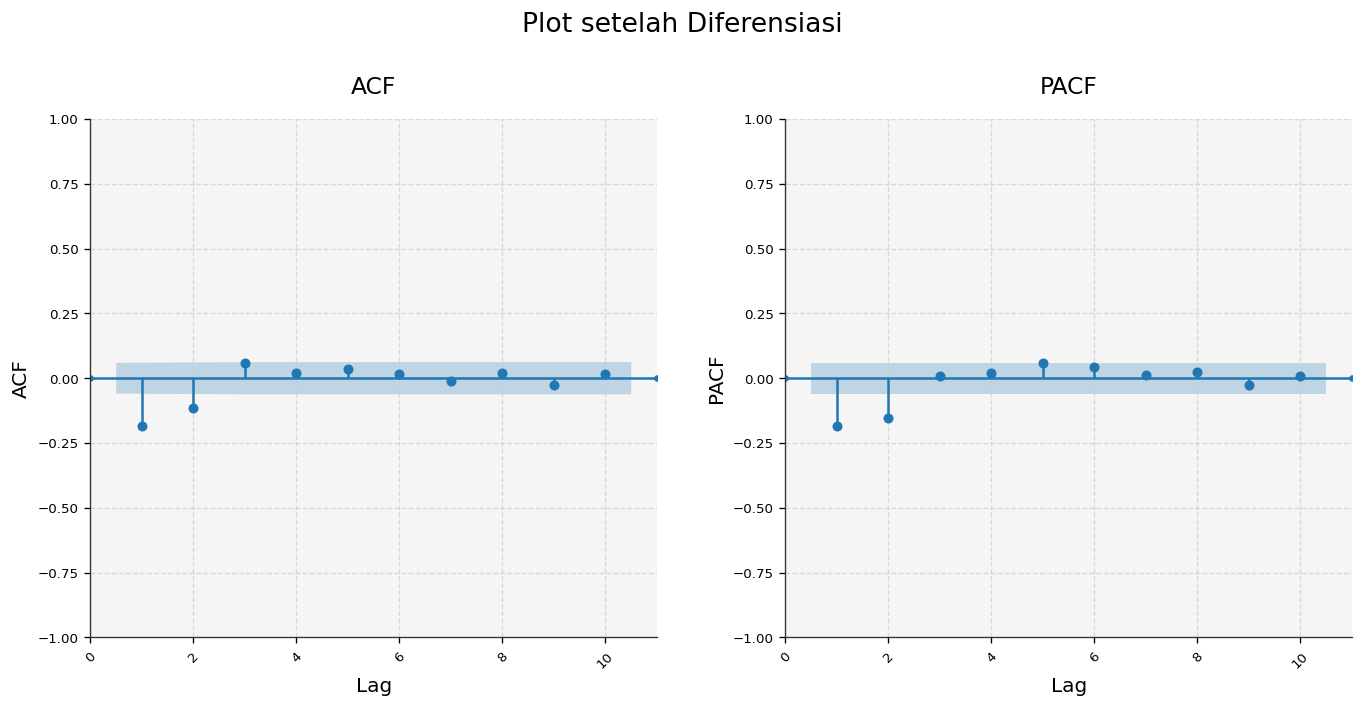

In [ ]:
data_diff = df_resampled['Terakhir_log'].diff().dropna()

lags = 10

# Setting aja
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.facecolor': '#f5f5f5',
    'grid.color': '#cccccc',
    'grid.linestyle': '--',
    'axes.edgecolor': '#333333',
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',
    'lines.markersize': 3,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']
})

fig, axes = plt.subplots(1, 2, sharey=False)

# --- Plot ACF ---
plot_acf(data_diff, ax=axes[0], lags=lags, alpha=0.05, zero=False)
axes[0].set_title('ACF', fontsize=14, pad=15)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Plot PACF ---
plot_pacf(data_diff, ax=axes[1], lags=lags, method='ywm', alpha=0.05, zero=False)
axes[1].set_title('PACF', fontsize=14, pad=15)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.suptitle('Plot setelah Diferensiasi', fontsize=16, y=1.02)
plt.show()

Dipunyai:
1. ACF: lag $3$ agak signifikan. $q=3$
2. PACF: lag $2$ agak signifikan. $p=2$

In [ ]:
# Fit ARIMA model (2,1,3)
model = ARIMA(df_resampled['Terakhir_log'], order=(2, 1, 3))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Terakhir_log   No. Observations:                 1096
Model:                 ARIMA(2, 1, 3)   Log Likelihood                3620.653
Date:                Tue, 10 Jun 2025   AIC                          -7229.307
Time:                        04:48:52   BIC                          -7199.315
Sample:                             0   HQIC                         -7217.958
                               - 1096                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5483      0.180      3.048      0.002       0.196       0.901
ar.L2          0.1373      0.205      0.671      0.502      -0.264       0.539
ma.L1         -0.7559      0.179     -4.216      0.0

Model ARIMA(2,1,3) yang diestimasi menunjukkan bahwa sebagian besar parameter signifikan secara statistik, terutama AR(1), MA(1), dan MA(3), dengan p-value < 0.05. Nilai AIC dan BIC yang rendah menunjukkan model cukup baik. Namun, hasil **Jarque-Bera** yang signifikan (p < 0.05) mengindikasikan bahwa residual tidak terdistribusi normal, dan uji **Heteroskedastisitas (H)** juga signifikan (p = 0.02), menandakan adanya **variasi varians residual** (ARCH effect). Hal ini mendukung perlunya pemodelan **volatilitas lanjutan menggunakan GARCH** untuk menangkap dinamika variansi yang tidak ditangkap ARIMA.

Meskipun begitu akan di lakukan iterasi untuk mendapatkan model yang lebih parsimoni dan memastikan best model.


Model ARIMA(2,1,3) cukup baik dalam menangkap pola data, terbukti dari nilai AIC yang rendah dan hasil uji Ljung-Box (p = 0.79) yang menunjukkan residual sudah acak (tidak ada autokorelasi). Namun, terdapat masalah pada normalitas dan heteroskedastisitas residual, terlihat dari uji Jarque-Bera dan uji Heteroskedastisitas yang signifikan. Artinya, meski model baik untuk prediksi, ada pelanggaran asumsi yang perlu diwaspadai untuk analisis lebih lanjut.

In [ ]:
p_range = range(0, 5)
d_range = range(1, 2)
q_range = range(0, 5)

all_models = []

print("Fitting ARIMA models...")
for p in p_range:
    for d in d_range:
        for q in q_range:
            try:
                model = ARIMA(df_resampled['Terakhir_log'], order=(p, d, q))
                model_fit = model.fit()

                resid = model_fit.resid.dropna()
                lb_result = sm.stats.acorr_ljungbox(resid, lags=[min(10, len(resid) - 1)], return_df=True)
                lb_pvalue = lb_result['lb_pvalue'].iloc[0]

                # Hitung jumlah parameter signifikan (p-value < 0.05)
                param_pvalues = model_fit.pvalues
                n_significant_params = np.sum(param_pvalues < 0.05)

                model_info = {
                    'p': p,
                    'd': d,
                    'q': q,
                    'order': f"({p},{d},{q})",
                    'AIC': model_fit.aic,
                    'BIC': model_fit.bic,
                    'ljung_box_pvalue': lb_pvalue,
                    'ljung_box_pass': lb_pvalue > 0.05,
                    'log_likelihood': model_fit.llf,
                    'params_count': len(model_fit.params),
                    'n_significant_params': n_significant_params
                }

                all_models.append(model_info)

            except Exception:
                continue

models_df = pd.DataFrame(all_models)

if not models_df.empty:
    # Tambahkan logika sort baru:
    models_df_sorted = models_df.sort_values(
        by=['ljung_box_pass', 'n_significant_params', 'AIC'],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    models_df_sorted['rank'] = range(1, len(models_df_sorted) + 1)

    display_columns = ['rank', 'order', 'AIC', 'BIC', 'ljung_box_pvalue',
                       'ljung_box_pass', 'n_significant_params', 'log_likelihood', 'params_count']
    models_df_display = models_df_sorted[display_columns].copy()

    print(f"\nModel Comparison Results ({len(models_df)} models fitted):")
    print("="*90)
    print(models_df_display.to_string(index=False, float_format='%.4f'))

    good_models = models_df_sorted[models_df_sorted['ljung_box_pass'] == True]

    if not good_models.empty:
        print(f"\nBest Models (Ljung-Box p-value > 0.05):")
        print("="*60)
        print(good_models[display_columns].head(10).to_string(index=False, float_format='%.4f'))

        best_model = good_models.iloc[0]
        print(f"\nRecommended Model: ARIMA{best_model['order']}")
        print(f"AIC: {best_model['AIC']:.4f}")
        print(f"BIC: {best_model['BIC']:.4f}")
        print(f"Significant Params: {best_model['n_significant_params']}")
        print(f"Ljung-Box p-value: {best_model['ljung_box_pvalue']:.4f}")

    else:
        print("\nNo models found with Ljung-Box p-value > 0.05.")
        print("Top 5 models by AIC:")
        print(models_df_sorted[display_columns].head(5).to_string(index=False, float_format='%.4f'))

else:
    print("No models could be fitted successfully.")

Fitting ARIMA models...

Model Comparison Results (25 models fitted):
 rank   order        AIC        BIC  ljung_box_pvalue  ljung_box_pass  n_significant_params  log_likelihood  params_count
    1 (3,1,4) -7214.8292 -7174.8411            1.0000            True                     7       3615.4146             8
    2 (4,1,4) -7219.8885 -7174.9019            1.0000            True                     6       3618.9442             9
    3 (1,1,3) -7231.1429 -7206.1504            1.0000            True                     4       3620.5715             5
    4 (2,1,3) -7229.3065 -7199.3155            1.0000            True                     4       3620.6533             6
    5 (0,1,4) -7228.4240 -7203.4314            1.0000            True                     4       3619.2120             5
    6 (0,1,3) -7227.1781 -7207.1841            1.0000            True                     4       3617.5891             4
    7 (2,1,0) -7226.6502 -7211.6547            1.0000            True       

Denga tetap mempertimbangkan parameter yang signfikan, didapatkan bahwa ARIMA (0,1,3) paling bagus terhadap transformasi logaritma dari ```Terakhir```.

In [ ]:
# Fit ARIMA model (0,1,3)
model = ARIMA(df_resampled['Terakhir_log'], order=(0, 1, 3))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Terakhir_log   No. Observations:                 1096
Model:                 ARIMA(0, 1, 3)   Log Likelihood                3617.589
Date:                Tue, 10 Jun 2025   AIC                          -7227.178
Time:                        05:01:50   BIC                          -7207.184
Sample:                             0   HQIC                         -7219.613
                               - 1096                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2077      0.022     -9.360      0.000      -0.251      -0.164
ma.L2         -0.1032      0.023     -4.460      0.000      -0.149      -0.058
ma.L3          0.0786      0.025      3.160      0.0

Kondisi ini menunjukkan bahwa meskipun model ARIMA mampu menangkap struktur dependensi mean, fluktuasi volatilitas residual belum sepenuhnya tertangkap oleh model. Oleh karena itu, untuk mengatasi masalah perubahan varians dari waktu ke waktu, diperlukan pengembangan model lanjutan seperti ARIMA-GARCH. Model ini memungkinkan kita untuk tetap menangkap pola nilai tengah dengan ARIMA, sambil mengakomodasi dinamika volatilitas melalui komponen GARCH,sehingga menghasilkan model yang lebih stabil dan realistis dalam merepresentasikan sifat data keuangan atau data deret waktu dengan volatilitas tinggi.

## **MODEL FINAL YANG DIAJUKAN**


$$\log(X_t) - \log(X_{t-1}) = \theta_1\epsilon_{t-1}+\theta_2\epsilon_{t-2}+\theta_3\epsilon_{t-2} + \epsilon_t$$


Secara tidak langsung
$$r_t= \phi_1 r_{t-1}+\phi_2 r_{t-2}+\epsilon_t$$
dengan $r_t$ adalah return ekivalen $r_t= log(X_t)-log(X_{t-1})$

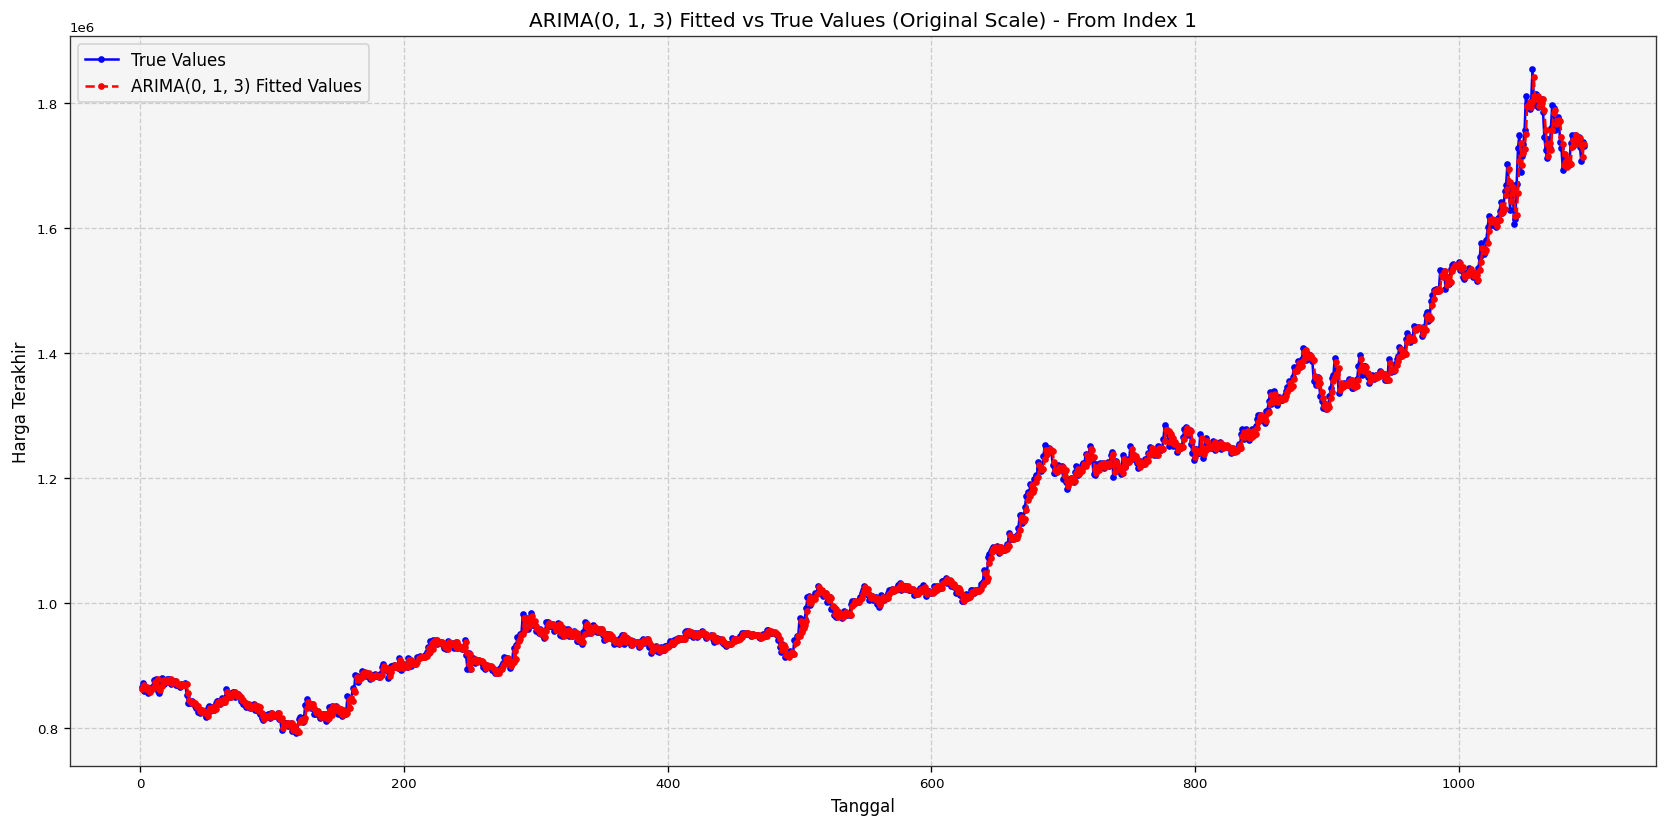

In [ ]:
def fit_arima_and_plot(df, order, log_transform=False):
    """
    Fits an ARIMA model to the provided DataFrame and plots the fitted values against the true values.

    Args:
        df (pd.DataFrame): The DataFrame containing the time series data.
        order (tuple): The order of the ARIMA model (p, d, q).
        log_transform (bool): Whether to apply log transformation to the data.
    """
    # Prepare the data
    if log_transform:
        df['Terakhir_log'] = np.log(df['Terakhir'])
        ts_data = df['Terakhir_log']
    else:
        ts_data = df['Terakhir']

    # Fit the ARIMA model
    model = ARIMA(ts_data, order=order)
    model_fit = model.fit()

    # Get fitted values
    fitted_values_log = model_fit.fittedvalues

    # Inverse transform the fitted values and true values (log -> original scale)
    if log_transform:
        fitted_values_original = np.exp(fitted_values_log)
        true_values_original = np.exp(ts_data)
    else:
        fitted_values_original = fitted_values_log
        true_values_original = ts_data

    # Plotting
    plt.figure(figsize=(14, 7))

    # Start plotting from index 1
    plt.plot(true_values_original.index[1:], true_values_original.iloc[1:], label='True Values', color='blue')
    plt.plot(fitted_values_original.index[1:], fitted_values_original.iloc[1:], label=f'ARIMA{order} Fitted Values', color='red', linestyle='--')

    plt.title(f'ARIMA{order} Fitted vs True Values (Original Scale) - From Index 1')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga Terakhir')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
fit_arima_and_plot(df_resampled, order=(0, 1, 3), log_transform=True)


# ARCH /GARCH

## Analisis Volatilitas Data

### Visualisasi $r_t$

In [ ]:
# Definisikan r_t = log (X_t) - log(X_{t-1})
df_resampled['r_t'] = np.log(df_resampled['Terakhir']) - np.log(df_resampled['Terakhir'].shift(1))

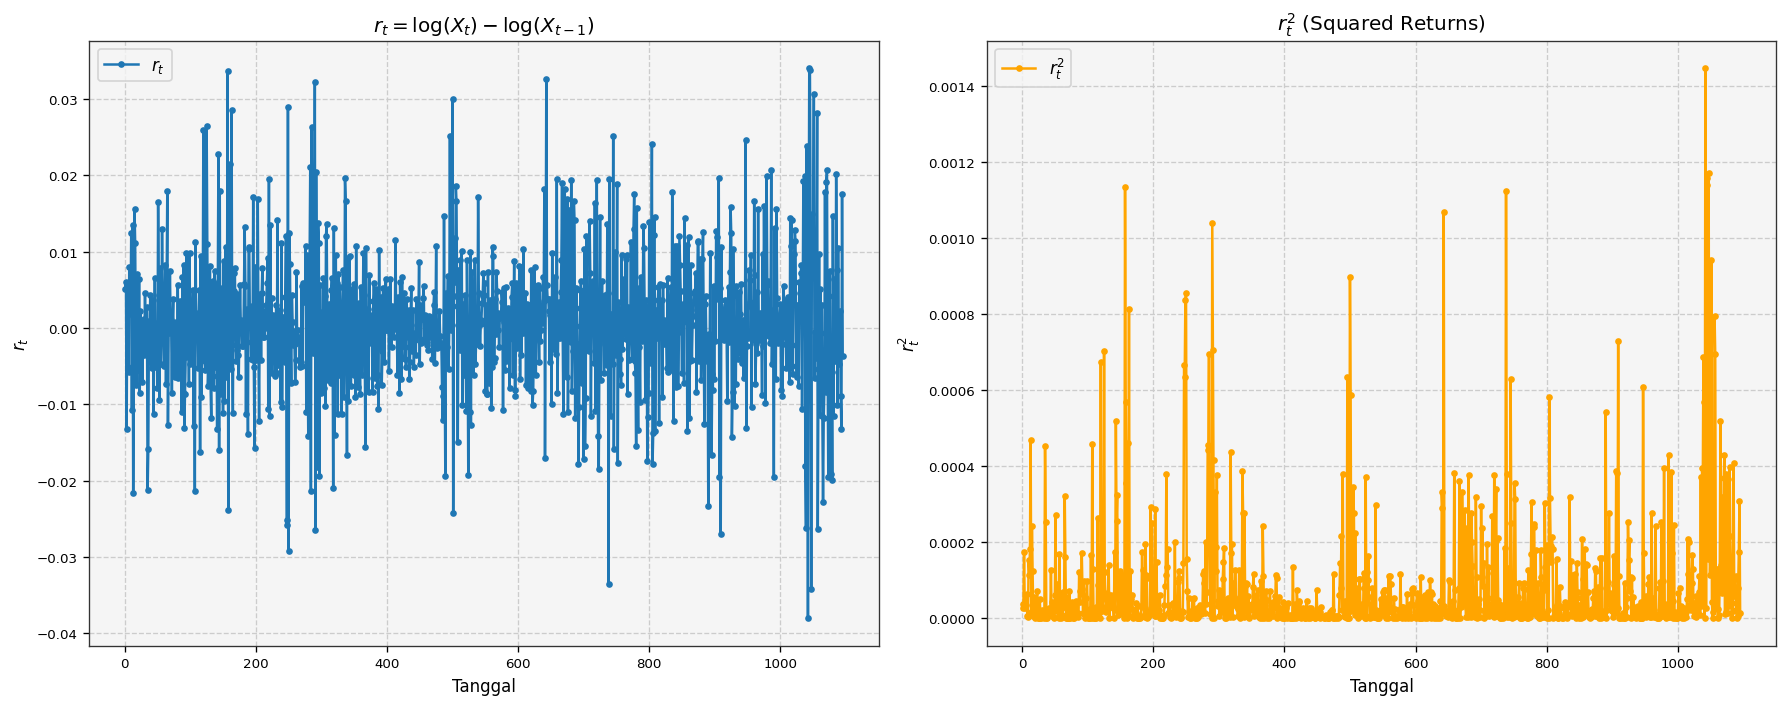

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot r_t
axes[0].plot(df_resampled.index, df_resampled['r_t'], label='$r_t$')
axes[0].set_title('$r_t = \log(X_t) - \log(X_{t-1})$')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('$r_t$')
axes[0].grid(True)
axes[0].legend()

# Plot r_t^2
axes[1].plot(df_resampled.index, df_resampled['r_t']**2, label='$r_t^2$', color='orange')
axes[1].set_title('$r_t^2$ (Squared Returns)')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('$r_t^2$')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


### Konfirmasi Volatilitas

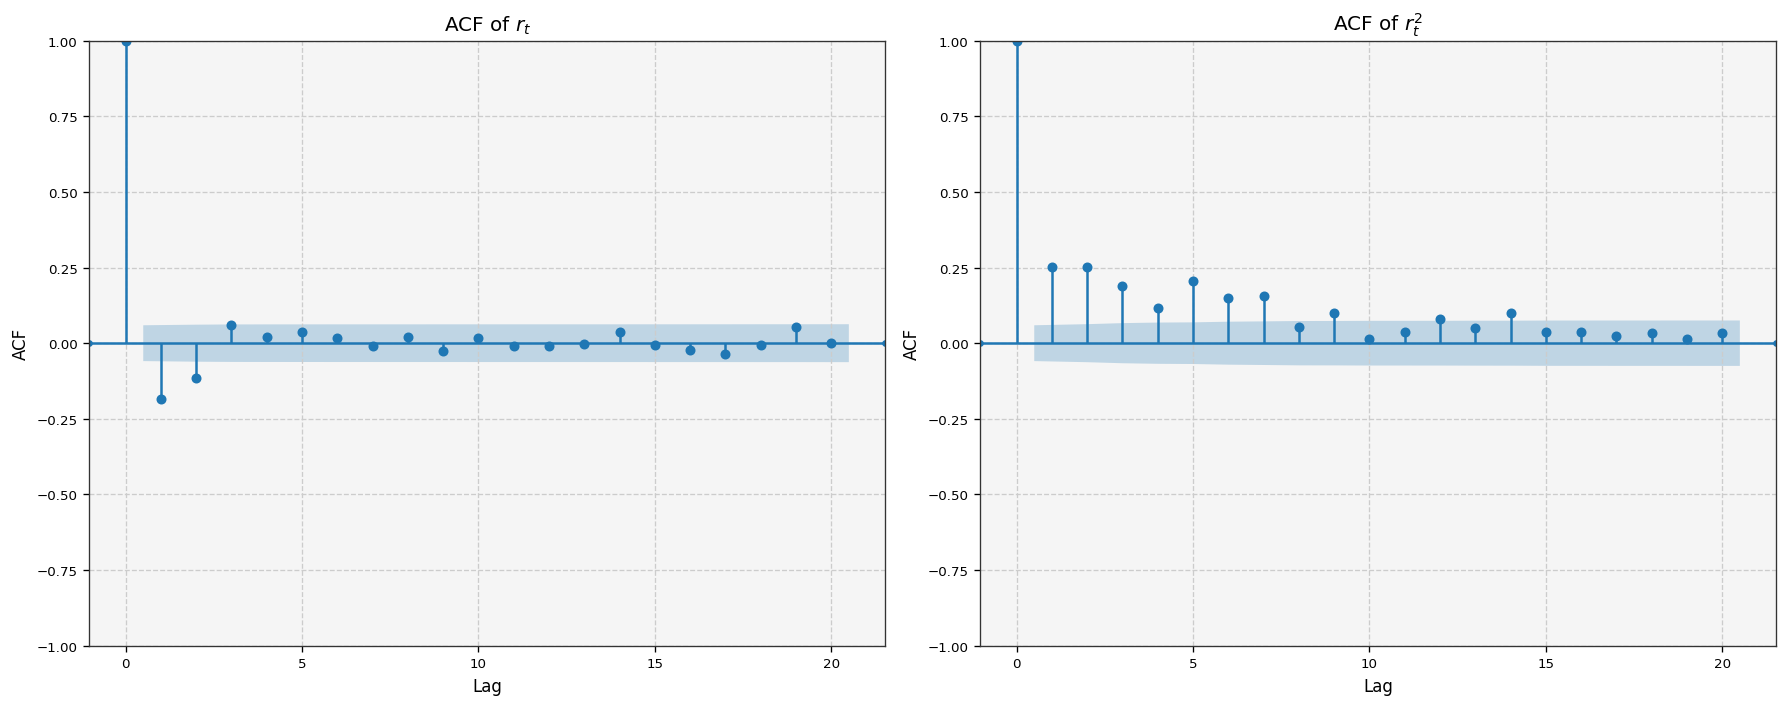

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot ACF of r_t
plot_acf(df_resampled['r_t'].dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF of $r_t$')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].grid(True)

# Plot ACF of r_t^2
plot_acf(df_resampled['r_t'].dropna()**2, lags=20, ax=axes[1])
axes[1].set_title('ACF of $r_t^2$')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].grid(True)

plt.tight_layout()
plt.show()


Dapat ditunjukkan bahwa Seri $r_t$ (return log) tidak berkorelasi, kecuali pada lag 1, yang mana merupakan hal umum untuk seri log-return — biasanya hanya memiliki sedikit autokorelasi pada lag awal, lalu cepat menjadi tidak berkorelasi.

Namun, seri kuadrat $r_t^2$ (yang merepresentasikan volatilitas) menunjukkan autokorelasi yang kuat bahkan hingga lag yang besar. Ini menandakan adanya clustering volatilitas, yaitu periode volatilitas tinggi atau rendah yang saling berdekatan.

### Karakteristik $r_t$


--- Skewness and Kurtosis of r_t ---
Skewness: 0.0898
Kurtosis: 1.6852


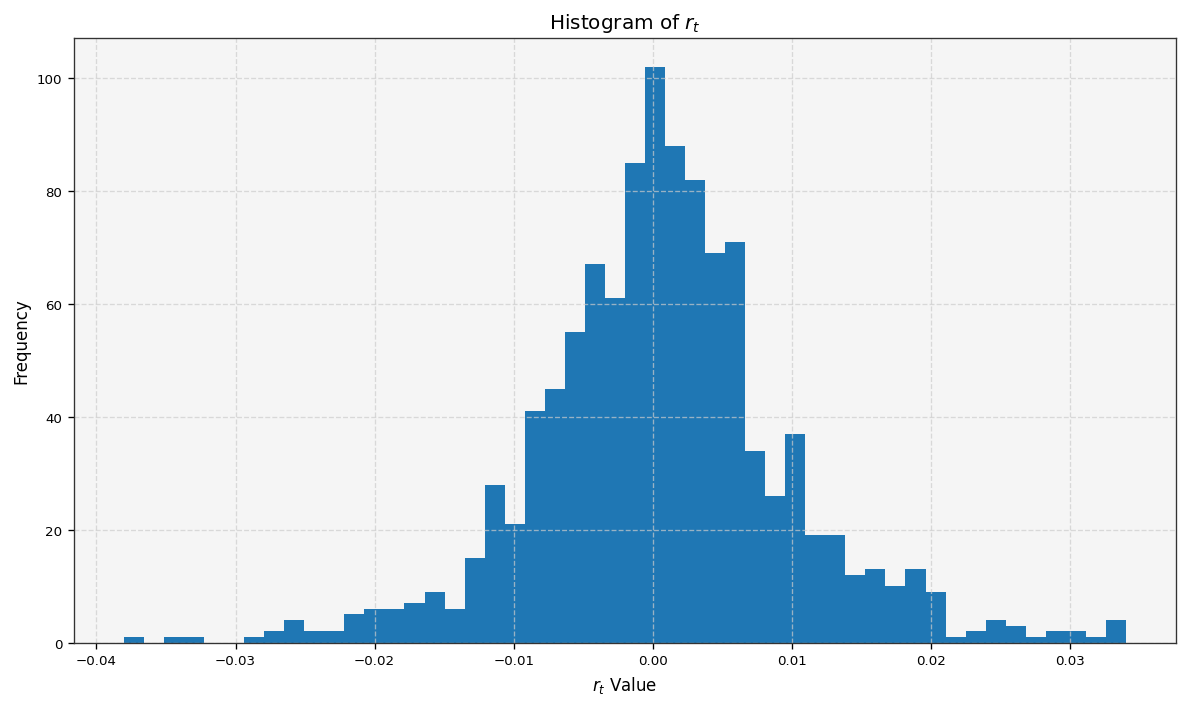

In [ ]:
print("\n--- Skewness and Kurtosis of r_t ---")
print(f"Skewness: {df_resampled['r_t'].skew():.4f}")
print(f"Kurtosis: {df_resampled['r_t'].kurtosis():.4f}")

plt.figure(figsize=(10, 6))
df_resampled['r_t'].hist(bins=50)
plt.title('Histogram of $r_t$')
plt.xlabel('$r_t$ Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

Skewwnes yang mendekati 0 menunjukkan bahwa distribusi mendekati normal sehingga tidak skewed. Pun, Distribusi ini tidak heavy-tailed — justru lebih flat atau light-tailed daripada normal. Akan dideteksi apakah terdapat efek GARCH sehingga perlu melakuakn pemodelan untuk menangkap volatilitas.

## Uji Heteroskedastisitas pada Residual ARIMA

### Uji LM-Test

In [ ]:
residuals = model_fit.resid.dropna()

# Perform the ARCH LM test
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(residuals) # Using lags=10 as an example

print(f'ARCH LM Test (Test for Heteroskedasticity) Results:')
print(f'  LM Statistic: {lm_stat:.4f}')
print(f'  LM p-value: {lm_pvalue:.4f}')
print(f'  F-statistic: {f_stat:.4f}')
print(f'  F p-value: {f_pvalue:.4f}')

alpha = 0.05
if lm_pvalue < alpha:
  print(f"Conclusion: Reject H0 - ARCH effects (conditional heteroskedasticity) are present (p-value = {lm_pvalue:.4f}). Consider using a GARCH model.")
else:
  print(f"Conclusion: Fail to reject H0 - No significant evidence of ARCH effects (constant conditional variance) (p-value = {lm_pvalue:.4f}).")

ARCH LM Test (Test for Heteroskedasticity) Results:
  LM Statistic: 141.4756
  LM p-value: 0.0000
  F-statistic: 16.1019
  F p-value: 0.0000
Conclusion: Reject H0 - ARCH effects (conditional heteroskedasticity) are present (p-value = 0.0000). Consider using a GARCH model.


Efek ARCH di deteksi, diperlukan pemodelan ARCH untuk menangkap volatilitas

## *Modelling Variance* GARCH

Model $GARCH(p,q)$ secara umum variansi bersyaratnya adalah
$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^q \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2
$$

Model $ARCH(p)$ secara umum variansi bersyaratnya adalah
$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^q \alpha_i \varepsilon_{t-i}^2
$$

Secara umum $r_t = \mu + \epsilon_t$

Pada kasus ini , akan dipertimbangkan ARCH terlebih dahulu, kemudian GARCH jika ARCH masih belum cukup baik

In [ ]:
df_resampled

,Tanggal,Terakhir,Terakhir_diff,Terakhir_log,r_t
0,2022-05-31,860950.0,NaN,13.665792,NaN
1,2022-06-01,865382.0,4432.0,13.670926,0.005135
2,2022-06-02,870661.0,5279.0,13.677008,0.006082
3,2022-06-03,859257.0,-11404.0,13.663823,-0.013185
4,2022-06-04,864062.5,4805.5,13.669400,0.005577
...,...,...,...,...,...
1091,2025-05-26,1745476.0,3947.0,14.372538,0.002264
1092,2025-05-27,1729984.0,-15492.0,14.363623,-0.008915
1093,2025-05-28,1707278.0,-22706.0,14.350411,-0.013212
1094,2025-05-29,1737467.0,30189.0,14.367939,0.017528


Plot Residual

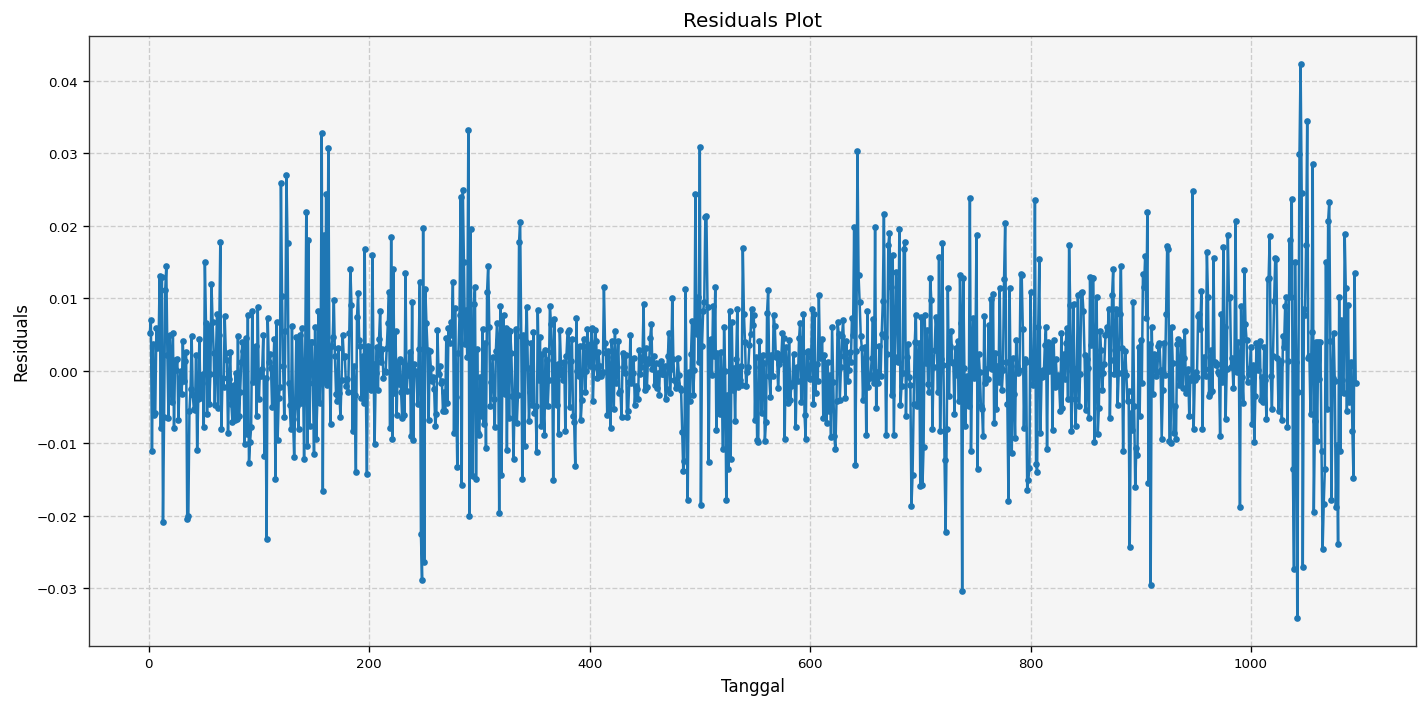

In [ ]:
def plot_residuals(model_fit):
    """
    Plots the residuals of a time series model.

    Args:
        model_fit: Fitted time series model object (e.g., from statsmodels ARIMA).
    """
    residuals = model_fit.resid.dropna()
    residuals_cleaned = residuals.iloc[1:]

    plt.figure(figsize=(12, 6))
    plt.plot(residuals_cleaned.index, residuals_cleaned)
    plt.title('Residuals Plot')
    plt.xlabel('Tanggal')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_residuals(model_fit)

## Analisis residual Pra-Pemodelan

AKibat difernsiasi, lag 1 punya resiudal yang tinggi

In [ ]:
residuals = model_fit.resid
residuals

,0
0,13.665792
1,0.005135
2,0.007023
3,-0.011122
4,0.003609
...,...
1091,0.001231
1092,-0.008261
1093,-0.014847
1094,0.013494


In [ ]:
residuals = model_fit.resid.dropna()
residuals_cleaned = residuals.iloc[1:]

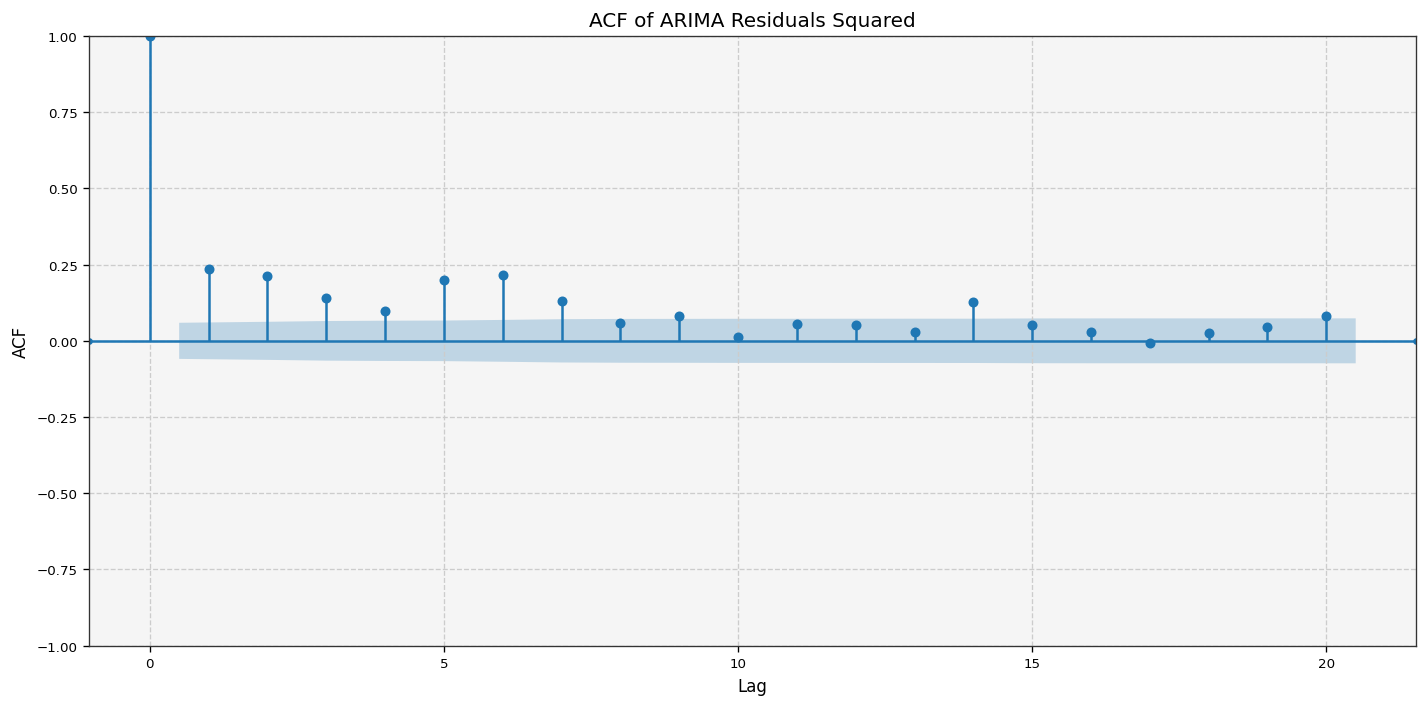

In [ ]:
plt.figure(figsize=(12, 6))
plot_acf(residuals_cleaned**2.
         , lags=20, ax=plt.gca())
plt.title('ACF of ARIMA Residuals Squared')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(True)
plt.tight_layout()
plt.show()


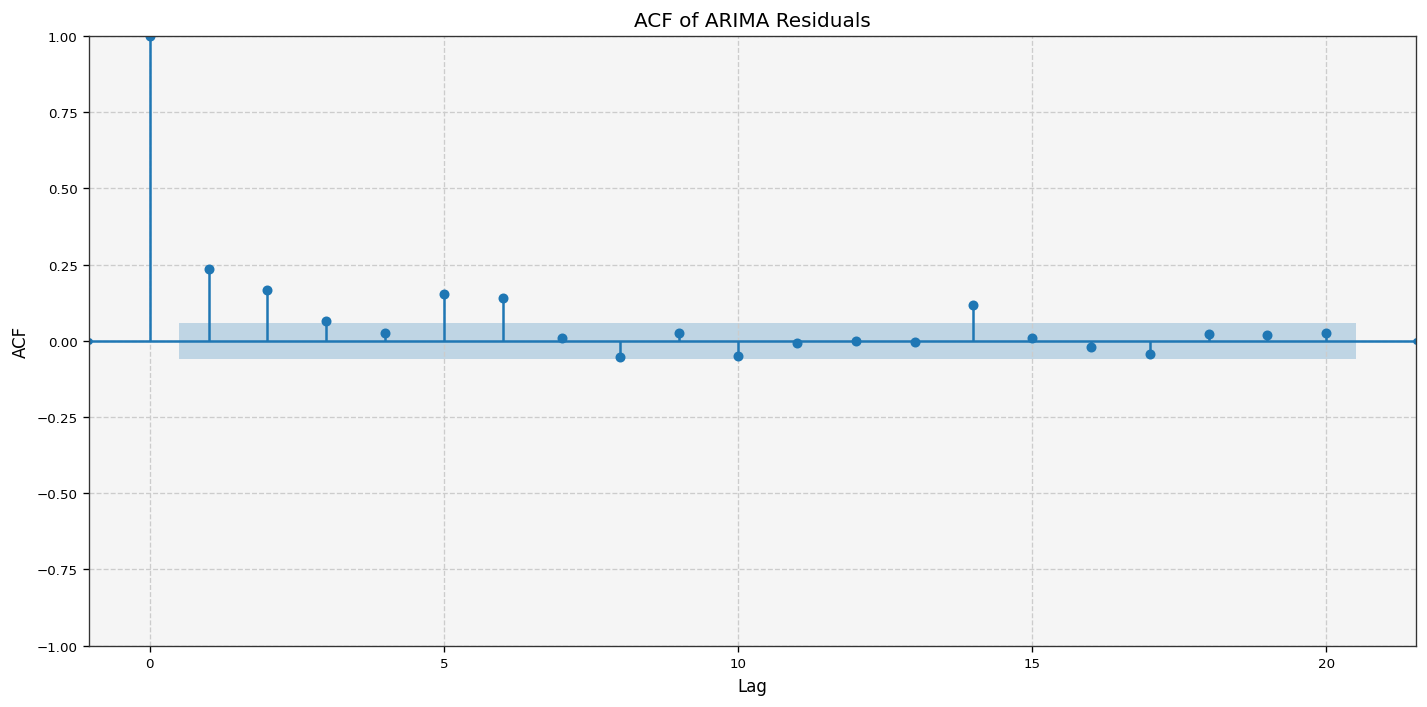

In [ ]:
plt.figure(figsize=(12, 6))
plot_pacf(residuals_cleaned**2.
         , lags=20, ax=plt.gca())
plt.title('ACF of ARIMA Residuals')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(True)
plt.tight_layout()
plt.show()

ACF residual dan ACF residual kuadrat menunjukkan data yang belum menangkap residual dengan baik. Akan dilakukan Fit ARCH

## Fit GARCH dari GARCH(1,1)

Akan digunakan model volatilitas paling umum dalam pemodelan data finansial yaitu $GARCH(1,1)$ sebagai model baseline.

In [ ]:
model_garch = arch_model(df_resampled['r_t'].dropna(), vol='Garch', p=1, q=1)
model_garch_fit = model_garch.fit(disp='off')
print(model_garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    r_t   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3660.38
Distribution:                  Normal   AIC:                          -7312.76
Method:            Maximum Likelihood   BIC:                          -7292.76
                                        No. Observations:                 1095
Date:                Tue, Jun 10 2025   Df Residuals:                     1094
Time:                        05:05:30   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         4.3797e-04  1.040e-05     42.123      0.000 [4.

Model GARCH(1,1) yang diterapkan menunjukkan bahwa **rata-rata *return*** adalah sekitar 0.0438% per periode, dan nilai ini signifikan secara statistik, mengindikasikan bahwa *return* rata-rata tidak nol. Selanjutnya, pada **persamaan volatilitas**, semua parameter terestimasi secara signifikan. Konstanta dasar varians ($\omega$) terestimasi sekitar $8.32 \times 10^{-6}$. Parameter $\alpha_1$ sebesar 0.2000 menunjukkan bahwa **guncangan atau *shocks*** pada periode sebelumnya memiliki dampak yang signifikan terhadap volatilitas saat ini. Sementara itu, parameter $\beta_1$ sebesar 0.7000 menunjukkan bahwa **volatilitas periode sebelumnya** juga memiliki dampak yang kuat dan signifikan terhadap volatilitas saat ini. Penjumlahan $\alpha_1 + \beta_1$ sebesar 0.9 mengindikasikan adanya **persistensi volatilitas yang tinggi**, sebuah karakteristik umum yang sering ditemukan pada data *return* aset keuangan. Secara keseluruhan, model GARCH(1,1) ini berhasil menangkap dinamika volatilitas data secara statistik.

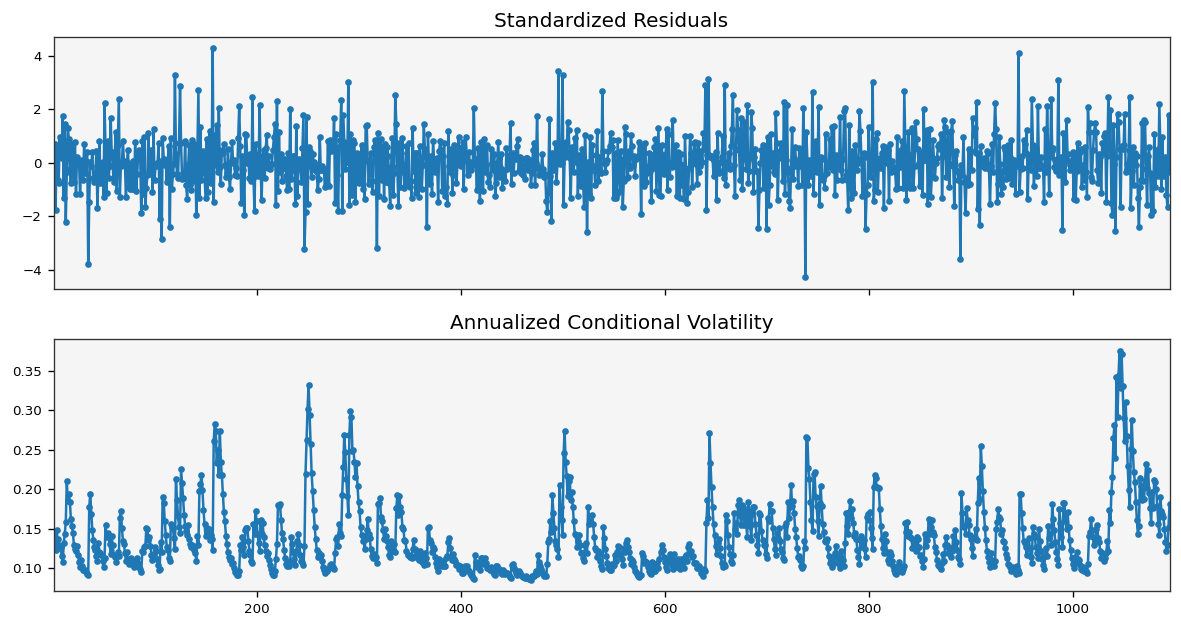

In [ ]:
model_garch_fit.plot(annualize='D')
plt.show()

Plot volatilitas menunjukkan klaster volatilitas yang jelas, di mana periode volatilitas tinggi dan rendah bergantian, mengonfirmasi keberhasilan model GARCH dalam menangkap fenomena ini. Selain itu, level volatilitas keseluruhan juga bervariasi seiring waktu, dan model GARCH tampak merespons shocks dalam data dengan meningkatkan estimasi volatilitas, seperti yang terlihat dari korelasi puncak pada plot volatilitas dengan lonjakan pada standardized residuals.

Residual hampir tersebar di sekitar 0 dan estimasi volatilitas bersyarat menunjukan bahwa GARCH mampu menangkap volatility clustering

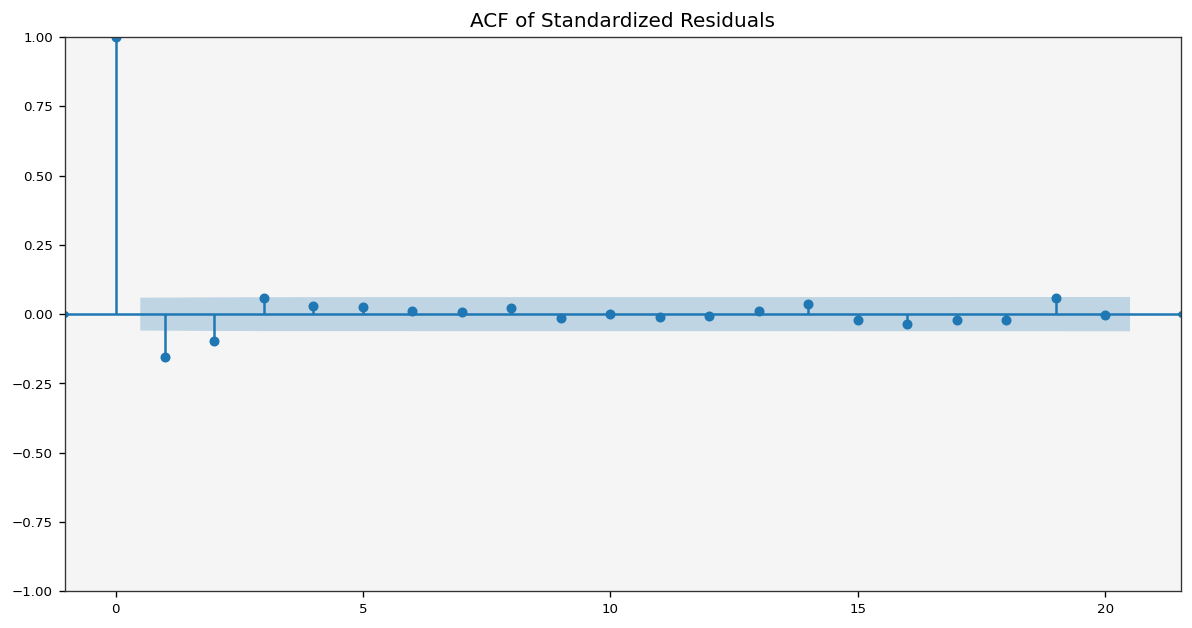

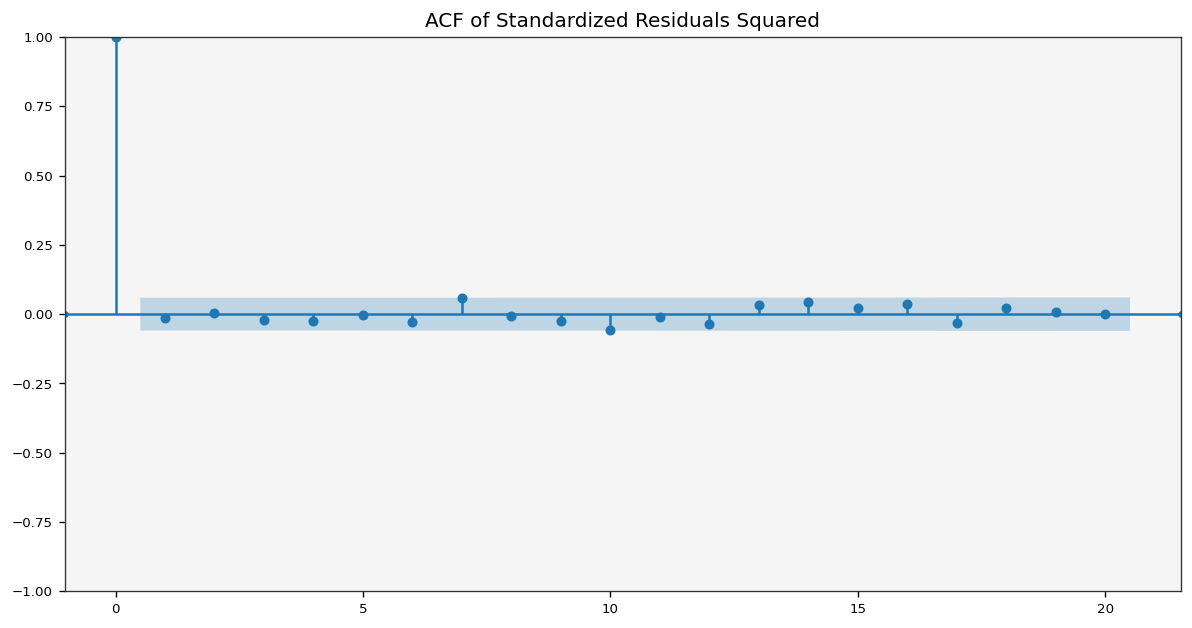

In [ ]:
resid = model_garch_fit.resid / model_garch_fit.conditional_volatility

plot_acf(resid, lags=20)
plt.title('ACF of Standardized Residuals')
plt.show()

plot_acf(resid**2, lags=20)
plt.title('ACF of Standardized Residuals Squared')
plt.show()

PACF dari standardized residual sudah merupakan white noise, tetapi ACF nya masih menangkap pola

In [ ]:
lb_test = sm.stats.acorr_ljungbox(resid, lags=[20], return_df=True)
print("Ljung-Box Test for Standardized Residuals:")
print(lb_test)

lb_test_squared = sm.stats.acorr_ljungbox(resid**2, lags=[20], return_df=True)
print("\nLjung-Box Test for Standardized Residuals Squared:")
print(lb_test_squared)


Ljung-Box Test for Standardized Residuals:
      lb_stat  lb_pvalue
20  51.780262   0.000123

Ljung-Box Test for Standardized Residuals Squared:
      lb_stat  lb_pvalue
20  18.301748   0.567538


Berdasarkan ACF PACF dan Ljung Box , GARCH(1,1) belum cukup baik dalam menangkap mean, maka dari itu perlu ditentukan meannya mengikuti pola apa.

## Tweak GARCH

In [ ]:
def garch_diagnostics(result: ARCHModelResult):
    """
    Melakukan diagnostik lengkap terhadap hasil fitting GARCH menggunakan standardized residual.

    Parameters:
    result : arch.univariate.base.ARCHModelResult
        Hasil fitting dari model GARCH.
    """

    # Drop NaN values from standardized residuals
    std_resid = result.std_resid.dropna()
    std_resid_squared = std_resid ** 2

    print("\n📋 MODEL SUMMARY:")
    print(result.summary())

    # === Plot standardized residuals ===
    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    axs = axs.flatten()

    axs[0].plot(std_resid)
    axs[0].set_title('Standardized Residuals')

    axs[1].plot(std_resid_squared)
    axs[1].set_title('Squared Standardized Residuals')

    plot_acf(std_resid, ax=axs[2])
    axs[2].set_title('ACF of Standardized Residuals')

    plot_acf(std_resid_squared, ax=axs[3])
    axs[3].set_title('ACF of Squared Standardized Residuals')

    sns.histplot(std_resid, kde=True, ax=axs[4])
    axs[4].set_title('Histogram of Standardized Residuals')

    stats.probplot(std_resid, dist="norm", plot=axs[5])
    axs[5].set_title("QQ Plot of Standardized Residuals")

    plt.tight_layout()
    plt.show()

    # === Ljung-Box Test ===
    # Ensure lags are appropriate for the remaining data after dropping NaNs
    max_lag = min(10, len(std_resid) // 2 - 1) # Adjust max lag based on data length
    if max_lag > 0:
        lb_resid = acorr_ljungbox(std_resid, lags=[max_lag], return_df=True)
        lb_sqresid = acorr_ljungbox(std_resid_squared, lags=[max_lag], return_df=True)

        print(f"\n📊 Ljung-Box Test on Standardized Residuals (lag {max_lag}):")
        print(lb_resid)

        print(f"\n📊 Ljung-Box Test on Squared Standardized Residuals (lag {max_lag}):")
        print(lb_sqresid)
    else:
        print("\n📊 Ljung-Box Test skipped due to insufficient data.")


    # === ARCH Test ===
    # Ensure lags are appropriate for the remaining data after dropping NaNs
    arch_lags = min(10, len(std_resid) // 2 - 1) # Adjust max lag for ARCH test
    if arch_lags > 0:
        arch_test = het_arch(std_resid, nlags=arch_lags)
        print(f"\n🔍 ARCH Test (Engle's Test) for Heteroskedasticity on Standardized Residuals (lags {arch_lags}):")
        print(f"LM stat = {arch_test[0]:.4f}, p-value = {arch_test[1]:.4f}")
    else:
        print("\n🔍 ARCH Test skipped due to insufficient data.")

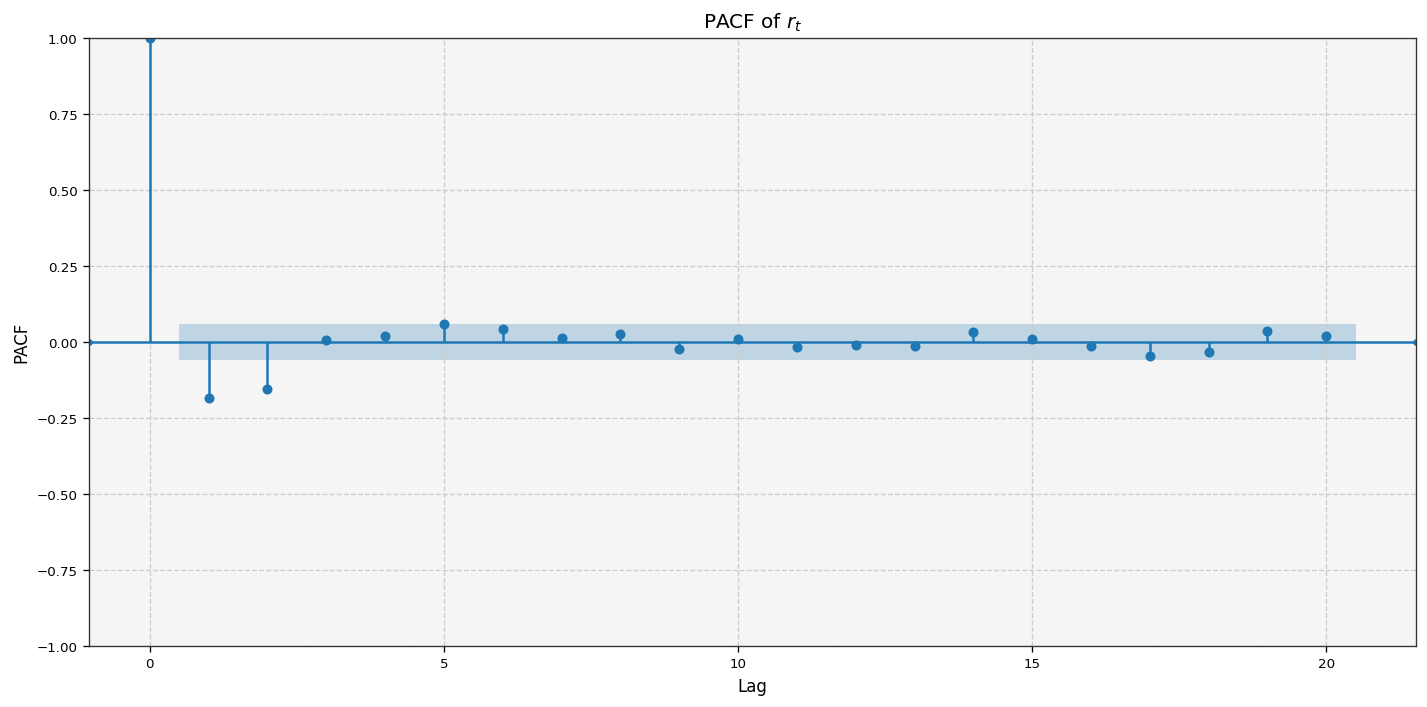

In [ ]:
# Plot PACF of r_t
plt.figure(figsize=(12, 6))
plot_pacf(df_resampled['r_t'].dropna(), lags=20, ax=plt.gca())
plt.title('PACF of $r_t$')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.grid(True)
plt.tight_layout()
plt.show()

Berkaca pada PACF dari residual ARIMA, mean residual signfikan pada lag -2


📋 MODEL SUMMARY:
                           AR - GARCH Model Results                           
Dep. Variable:                    r_t   R-squared:                       0.057
Mean Model:                        AR   Adj. R-squared:                  0.055
Vol Model:                      GARCH   Log-Likelihood:                3680.57
Distribution:                  Normal   AIC:                          -7349.14
Method:            Maximum Likelihood   BIC:                          -7319.16
                                        No. Observations:                 1093
Date:                Tue, Jun 10 2025   Df Residuals:                     1090
Time:                        05:06:55   Df Model:                            3
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const      6.3809e-04  4.193e-05     15.

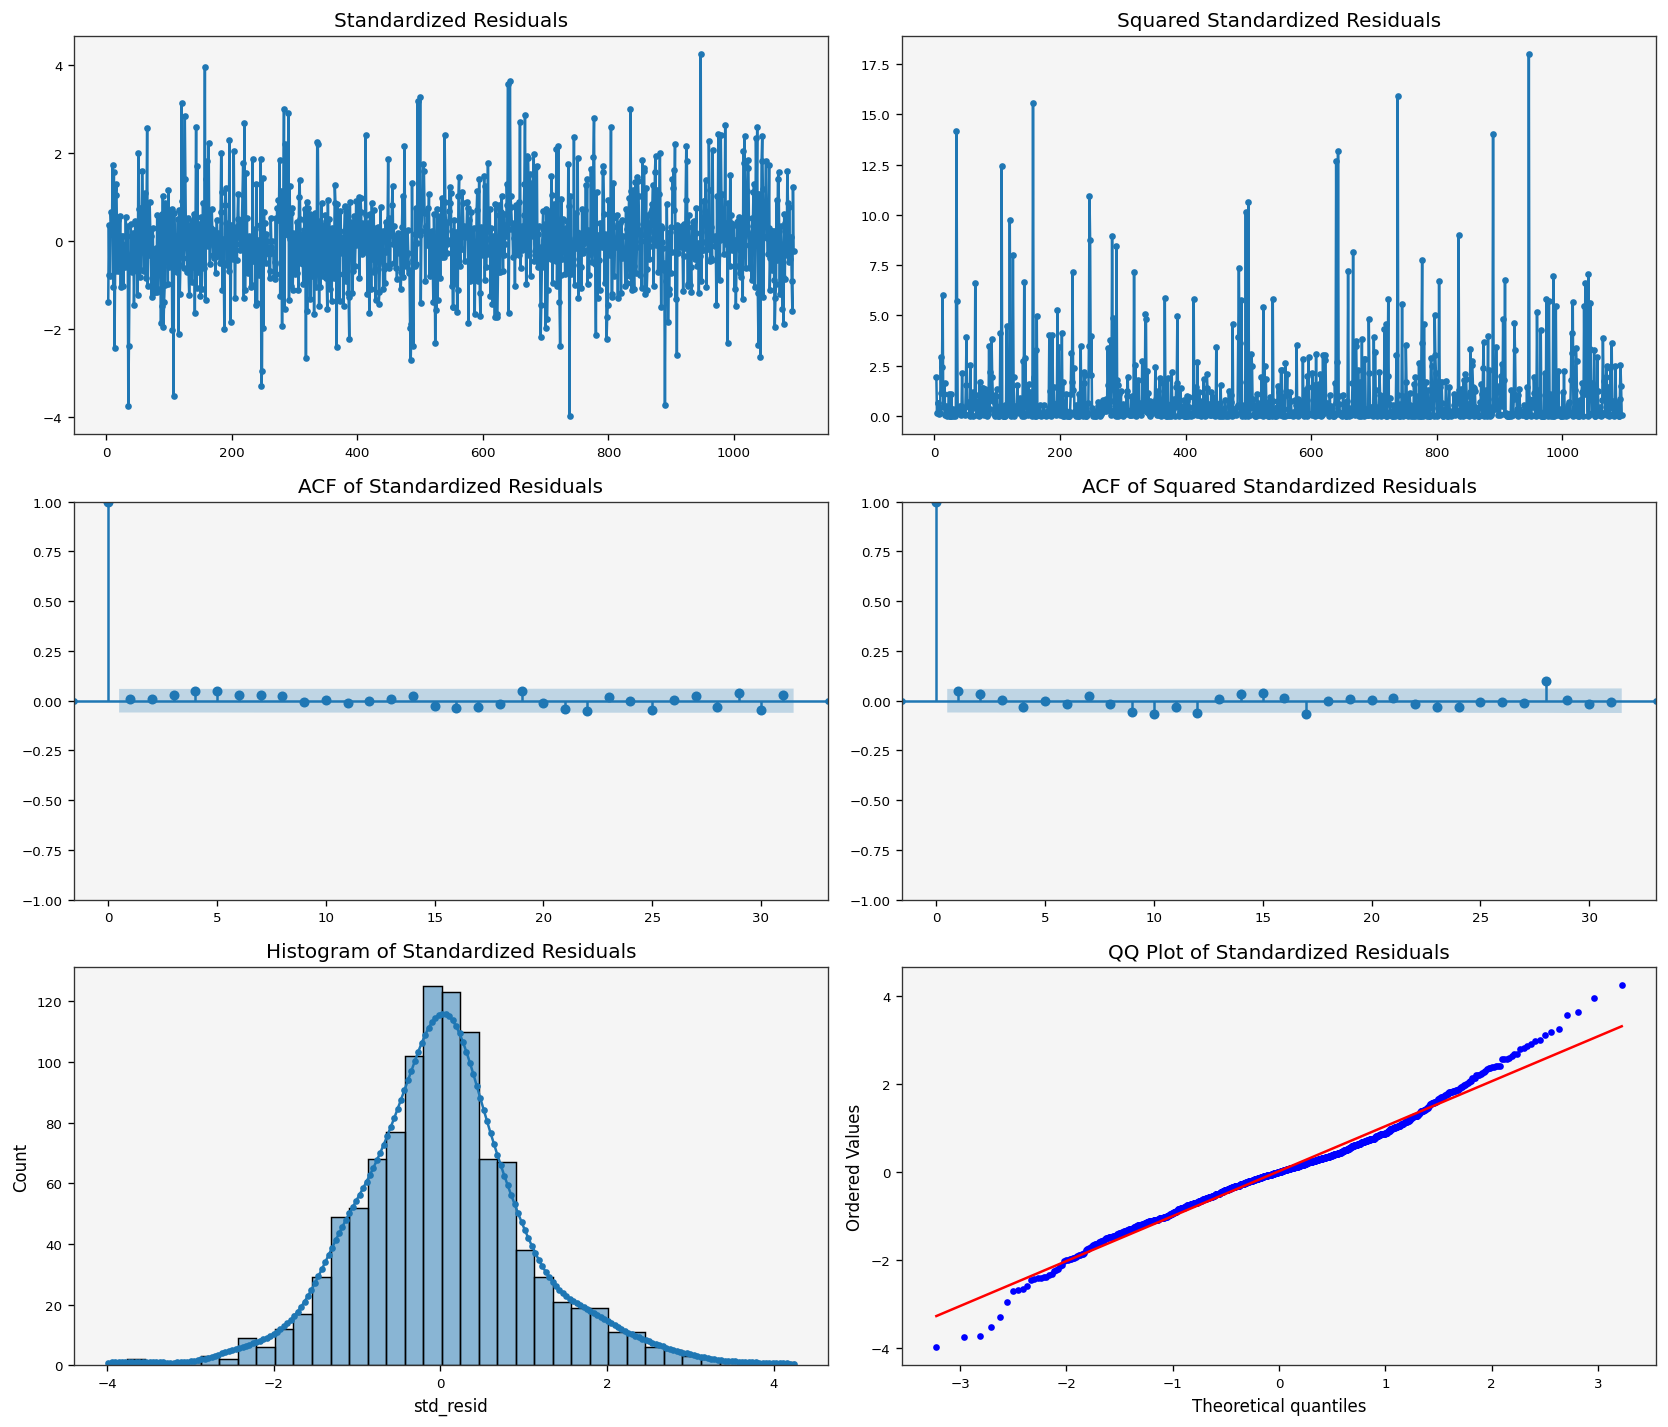


📊 Ljung-Box Test on Standardized Residuals (lag 10):
    lb_stat  lb_pvalue
10  8.72206   0.558669

📊 Ljung-Box Test on Squared Standardized Residuals (lag 10):
      lb_stat  lb_pvalue
10  15.432696   0.117065

🔍 ARCH Test (Engle's Test) for Heteroskedasticity on Standardized Residuals (lags 10):
LM stat = 14.4400, p-value = 0.1539


In [ ]:
model_garch1 = arch_model(df_resampled['r_t'].dropna(), mean='AR', lags=2, vol='GARCH', p=1, q=1)

model_garch_fit = model_garch1.fit(disp='off')

garch_diagnostics(model_garch_fit)

SEMUANYA AMAN.

Berdasarkan hasil estimasi, model ARIMA(0,1,3)-GARCH(1,1) terbukti mampu menangkap dinamika return dan volatilitas data secara signifikan. Komponen AR(1) dan AR(2) pada mean equation menunjukkan bahwa return saat ini secara signifikan dipengaruhi oleh dua lag sebelumnya. Ini mengindikasikan adanya autokorelasi jangka pendek dalam pergerakan return.

Sementara itu, pada variance equation, parameter alpha(1) dan beta(1) signifikan, serta nilai beta(1) = 0.88 mengindikasikan adanya efek volatilitas yang persisten (volatility clustering). Nilai omega yang sangat kecil namun signifikan mendukung kestabilan model GARCH.

Uji diagnostik residual, seperti:

- Ljung-Box test menunjukkan tidak ada autokorelasi tersisa pada residual maupun squared residual (p > 0.05),

- ARCH test menunjukkan tidak terdapat heteroskedastisitas yang tersisa (p = 0.15), menandakan bahwa model telah cukup baik dalam menjelaskan struktur varians dalam data.

Secara keseluruhan, model ARIMA(0,1,3)-GARCH(1,1) dinilai sesuai untuk memodelkan dinamika mean dan volatilitas dari data return, serta dapat digunakan untuk keperluan peramalan.

# ARSIP

In [ ]:
# residuals = model_fit.resid.dropna()

# # Perform the ARCH LM test
# lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(residuals) # Using lags=10 as an example

# print(f'ARCH LM Test (Test for Heteroskedasticity) Results:')
# print(f'  LM Statistic: {lm_stat:.4f}')
# print(f'  LM p-value: {lm_pvalue:.4f}')
# print(f'  F-statistic: {f_stat:.4f}')
# print(f'  F p-value: {f_pvalue:.4f}')

# alpha = 0.05
# if lm_pvalue < alpha:
#   print(f"Conclusion: Reject H0 - ARCH effects (conditional heteroskedasticity) are present (p-value = {lm_pvalue:.4f}). Consider using a GARCH model.")
# else:
#   print(f"Conclusion: Fail to reject H0 - No significant evidence of ARCH effects (constant conditional variance) (p-value = {lm_pvalue:.4f}).")
